In [5]:
%pip install matplotlib

  Using cached matplotlib-3.9.1-cp39-cp39-win_amd64.whl (8.0 MB)
  Using cached pyparsing-3.1.2-py3-none-any.whl (103 kB)
  Using cached kiwisolver-1.4.5-cp39-cp39-win_amd64.whl (56 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached fonttools-4.53.1-cp39-cp39-win_amd64.whl (2.2 MB)
  Using cached importlib_resources-6.4.0-py3-none-any.whl (38 kB)
  Using cached contourpy-1.2.1-cp39-cp39-win_amd64.whl (182 kB)
  Using cached pillow-10.4.0-cp39-cp39-win_amd64.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\andyk\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.

[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: C:\Users\andyk\AppData\Local\Programs\Python\Python37\python.exe -m pip install --upgrade pip


In [7]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\andyk\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [1]:
import sys
import os

base_dir = 'c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl'
# pretend you're in the normal directory
os.chdir(base_dir)
print(os.getcwd())

# in order to access all the other stuff
# hate path manipulation so much why can't coding be easy
sys.path.append(base_dir)
sys.path

c:\Users\andyk\OneDrive\Documents\GitHub\puente-serverless\puente-analytics-service\lambdas\etl


['c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl\\notebooks',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\python39.zip',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\DLLs',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\lib',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39',
 '',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\win32',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\win32\\lib',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\Pythonwin',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages',
 'c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl']

In [8]:
from sqlalchemy import create_engine
import psycopg2
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shared_modules.env_utils import PG_HOST, PG_DATABASE, PG_PORT, PG_USERNAME, PG_PASSWORD
from shared_modules.utils import connection

In [10]:
conn = connection()
cursor = conn.cursor()
engine = create_engine(f'postgresql://{PG_USERNAME}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}')

In [33]:
env_health_qry = """
select sf.*, fd.*, qd.*, sod.name AS surveying_organization
from survey_fact sf 
join form_dim fd 
on fd."uuid"  = sf.form_id 
join question_dim qd 
on qd."uuid"  = sf.question_id 
join surveying_organization_dim sod
on sod."uuid" = sf.surveying_organization_id
where fd.name = 'HistoryEnvironmentalHealth'
"""
env_health = pd.read_sql(env_health_qry, engine)
env_health

,uuid,surveying_organization_id,surveying_user_id,community_id,question_id,question_answer,created_at,updated_at,form_id,patient_id,...,updated_at,uuid,question,field_type,formik_key,options,created_at,updated_at,form_id,surveying_organization
0,84a8d20f-3842-4922-b90b-9db2eb00ed8f,1965ba21-1b96-383f-9581-33ad74c0755e,8817d7f3-28be-3e7c-b480-33acefd94172,aa328ed0-132b-3d11-ae96-21943c38e909,43d55317-c1d6-31cc-b8d6-5e5e445acf15,{Water},2021-11-26 14:51:19.337,2021-11-26 14:51:19.337,732f50b7-6220-38b1-81b8-1f2c00ead024,8d37f4ac-4ba5-3d69-a042-136de136a432,...,2024-04-15 19:06:12.724350,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Puente
1,93ecfe91-9f3e-4905-867a-5f24209d960d,1965ba21-1b96-383f-9581-33ad74c0755e,106f3ec4-af5b-3b0c-8746-cfcc1410cb2a,aa328ed0-132b-3d11-ae96-21943c38e909,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{Water,Trash}",2021-11-26 14:50:47.068,2021-11-26 14:50:47.068,732f50b7-6220-38b1-81b8-1f2c00ead024,b40367bf-be5d-39fe-9eb9-d4d3de60fd59,...,2024-04-15 19:06:12.724350,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Puente
2,af2cfd61-20c7-457f-8a48-b3ab5e964454,1965ba21-1b96-383f-9581-33ad74c0755e,41bce3e3-8fed-3dc9-84c5-0a9a64250405,aa328ed0-132b-3d11-ae96-21943c38e909,43d55317-c1d6-31cc-b8d6-5e5e445acf15,{Water},2021-11-26 14:45:46.745,2021-11-26 14:45:46.745,732f50b7-6220-38b1-81b8-1f2c00ead024,bcd2befa-cba3-388c-a19a-7abaa3b85d81,...,2024-04-15 19:06:12.724350,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Puente
3,ff38637e-1314-43e3-9ebd-103967adb622,1965ba21-1b96-383f-9581-33ad74c0755e,8817d7f3-28be-3e7c-b480-33acefd94172,aa328ed0-132b-3d11-ae96-21943c38e909,43d55317-c1d6-31cc-b8d6-5e5e445acf15,{Water},2021-11-26 14:45:04.093,2021-11-26 14:45:04.093,732f50b7-6220-38b1-81b8-1f2c00ead024,d04293a3-8cec-364e-a15e-189b653c47e2,...,2024-04-15 19:06:12.724350,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Puente
4,ad1fe268-0c96-42a9-9b36-cc76c058a09d,1965ba21-1b96-383f-9581-33ad74c0755e,106f3ec4-af5b-3b0c-8746-cfcc1410cb2a,aa328ed0-132b-3d11-ae96-21943c38e909,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{Water,Street}",2021-11-26 14:43:37.727,2021-11-26 14:43:37.727,732f50b7-6220-38b1-81b8-1f2c00ead024,bb47155c-36f6-3209-b157-12aa232c1594,...,2024-04-15 19:06:12.724350,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Puente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282321,74d6e8cb-1289-41f2-bec9-cfe7c72837d5,622b5e3b-ab21-3a1f-a41e-97d5104f5e9d,6543533d-3bb4-3de0-87be-42531127804d,b5ec1822-c6b2-3851-9b52-f9ca3a158615,f497fffe-0608-30b3-9043-1d1912bcc550,{None},2022-11-05 22:57:01.483,2023-03-23 23:06:00.172,732f50b7-6220-38b1-81b8-1f2c00ead024,a9d17eaf-d911-3ec6-991f-3d523ad0e841,...,2024-04-15 19:06:12.724350,f497fffe-0608-30b3-9043-1d1912bcc550,environmentalHealth.clinicAccess.label,selectMulti,clinicAccess_v2,"[Clinic_Medical_Center, Polyclinic, Hospital, ...",2024-04-15 19:06:12.727352,2024-04-15 

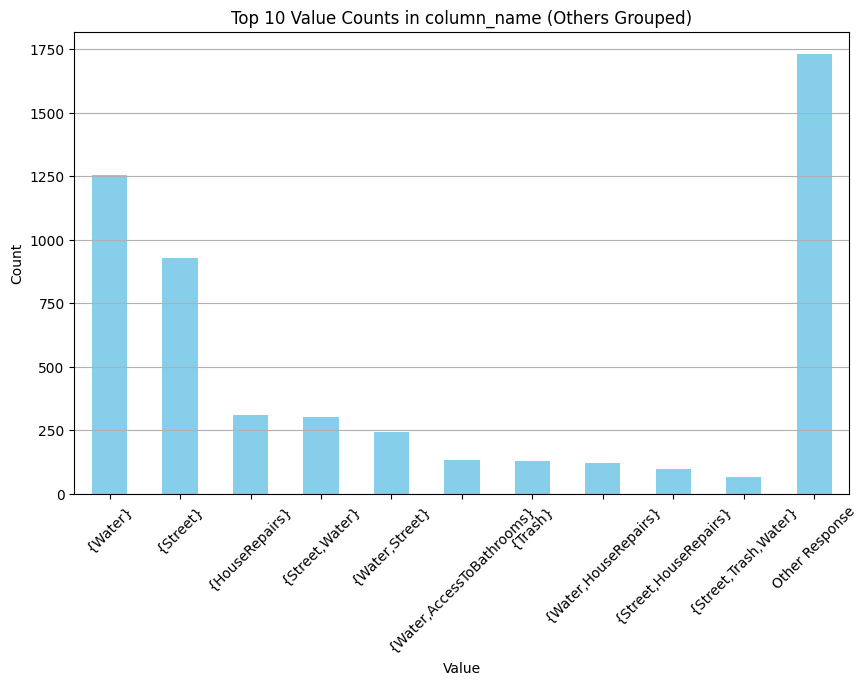

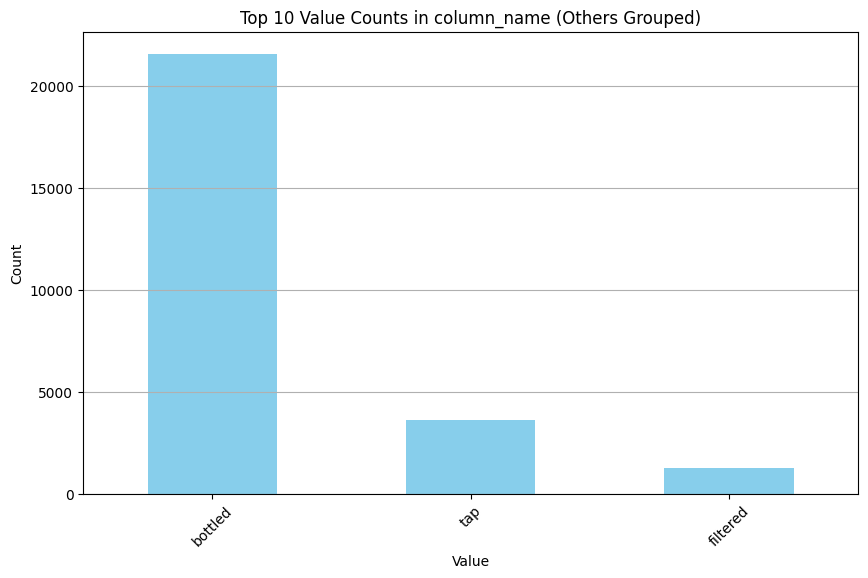

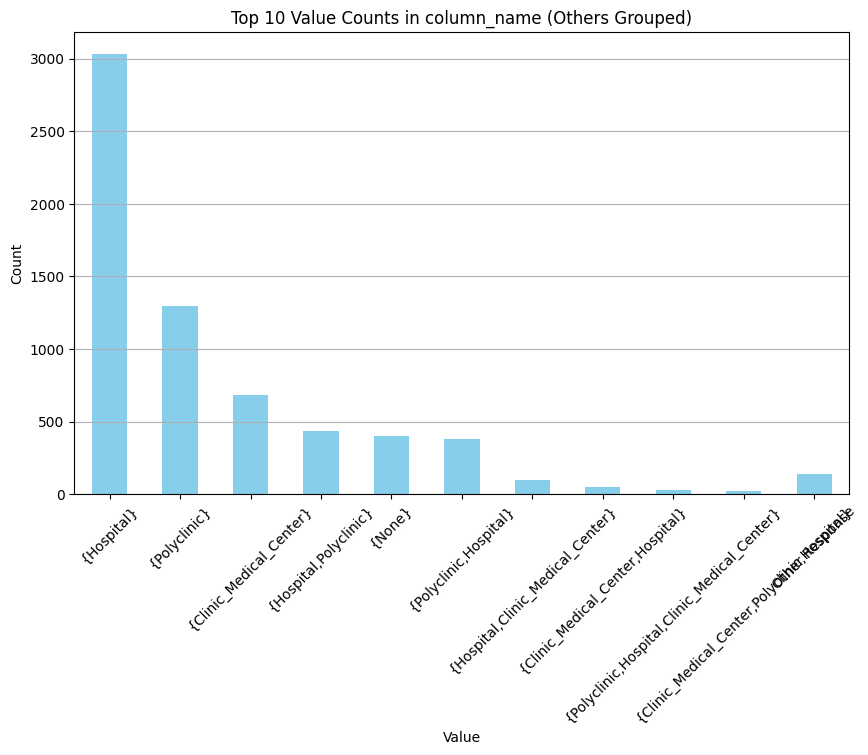

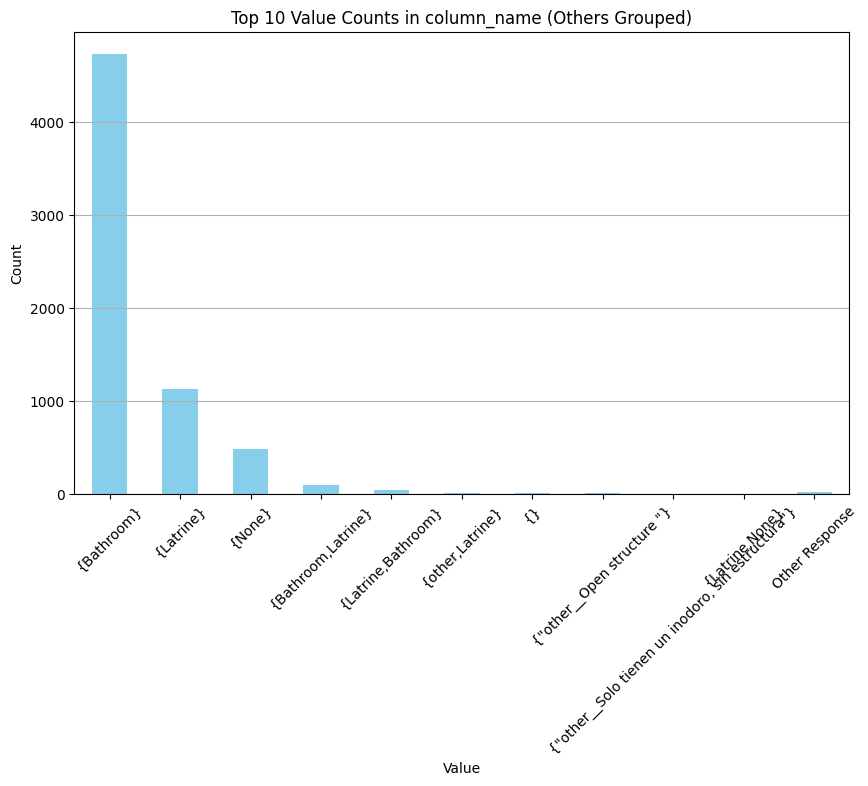

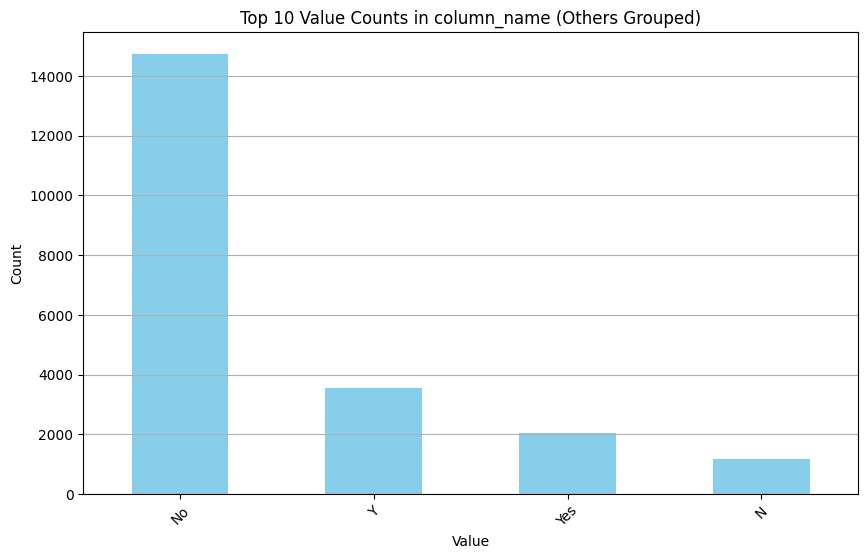

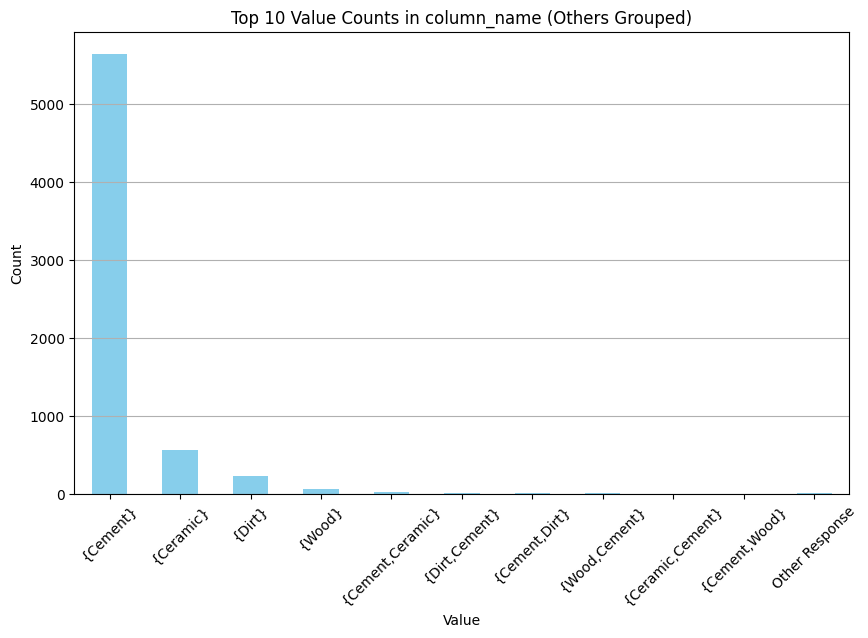

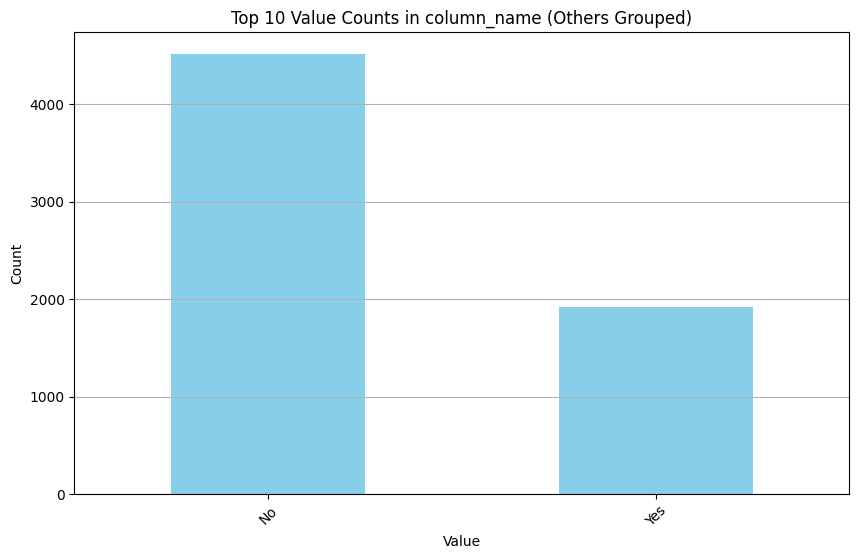

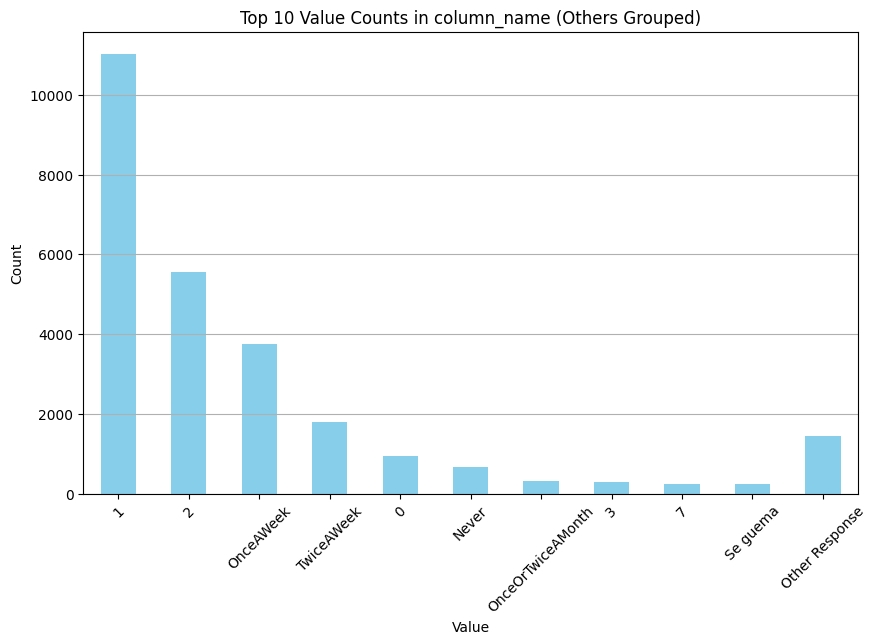

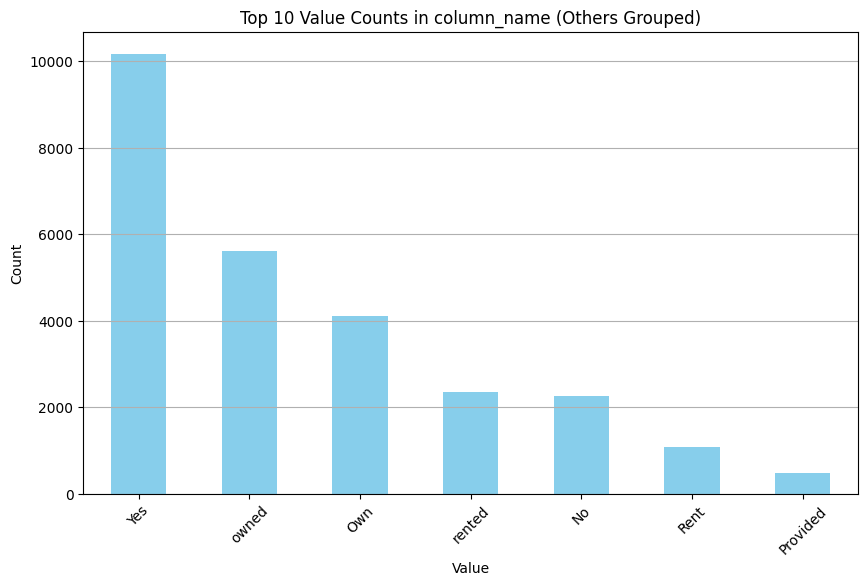

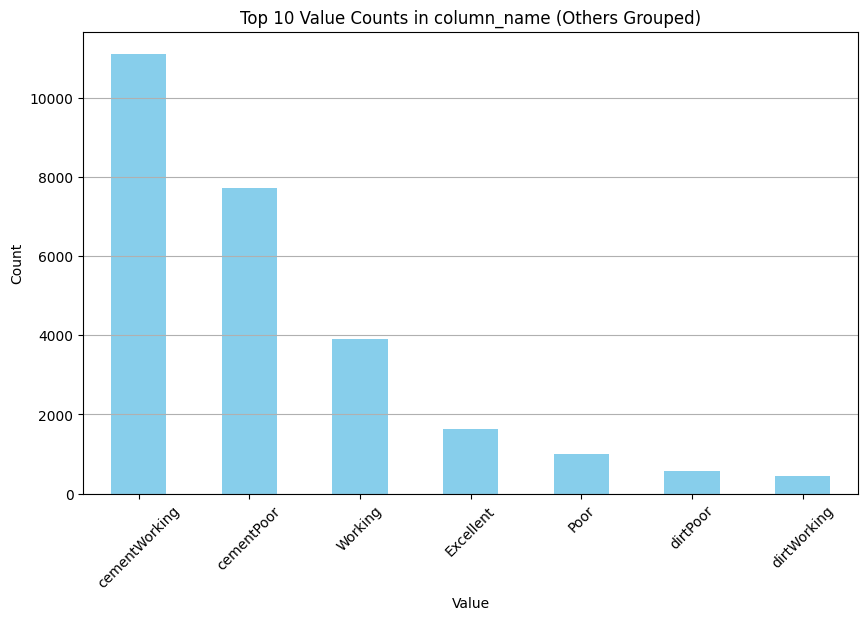

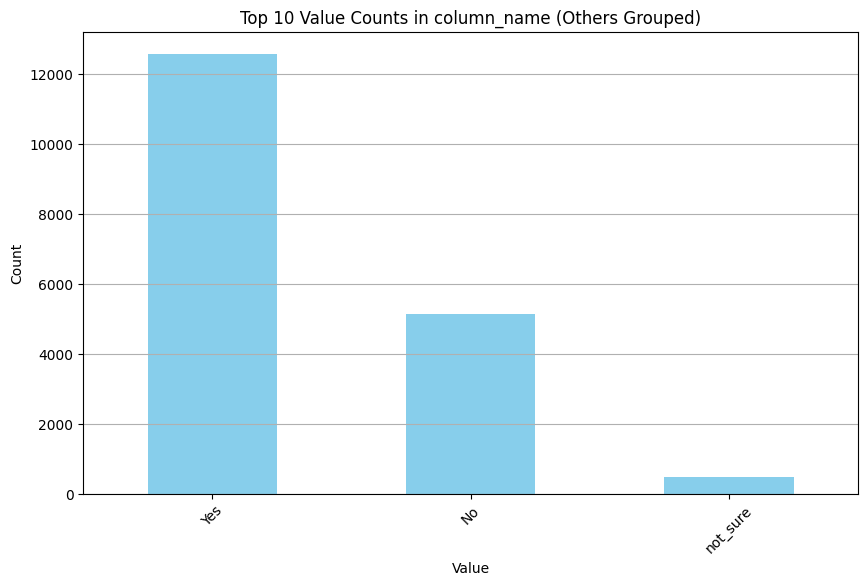

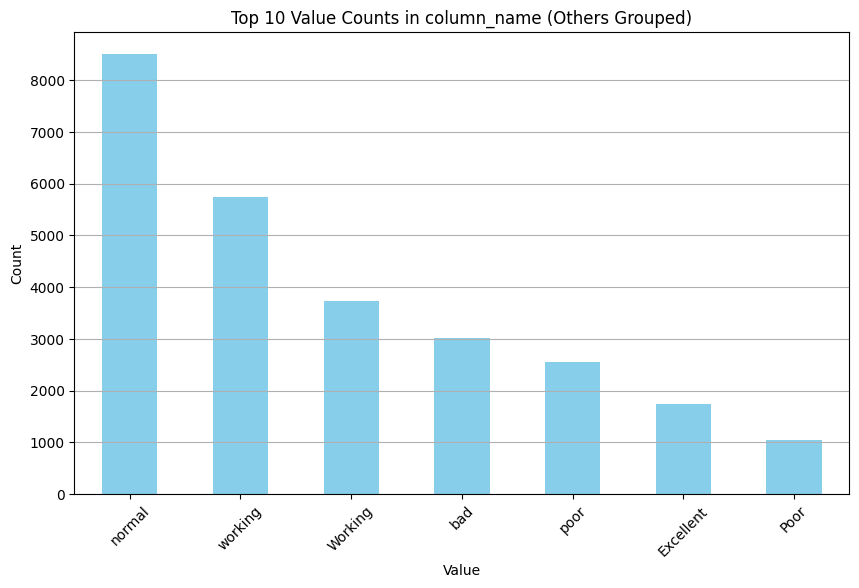

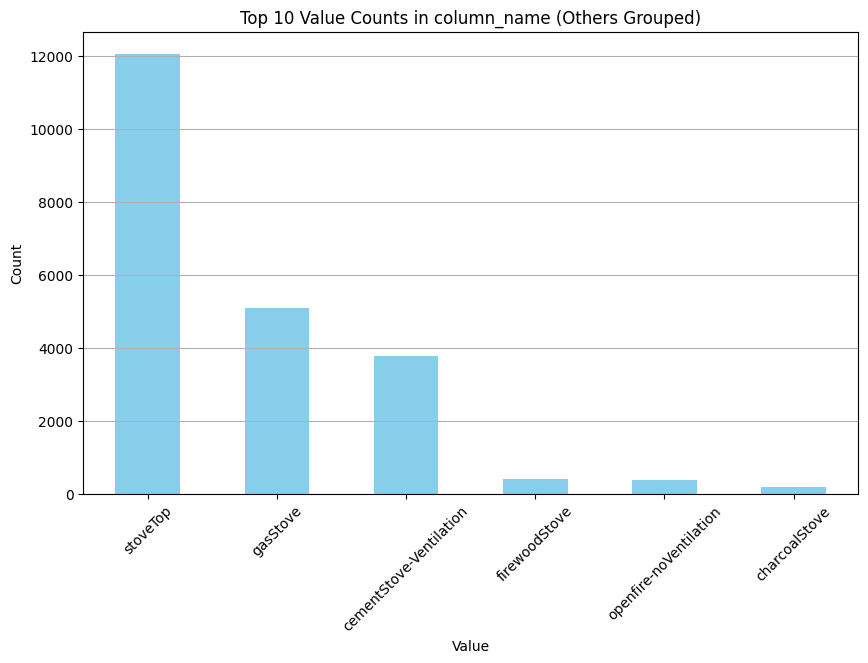

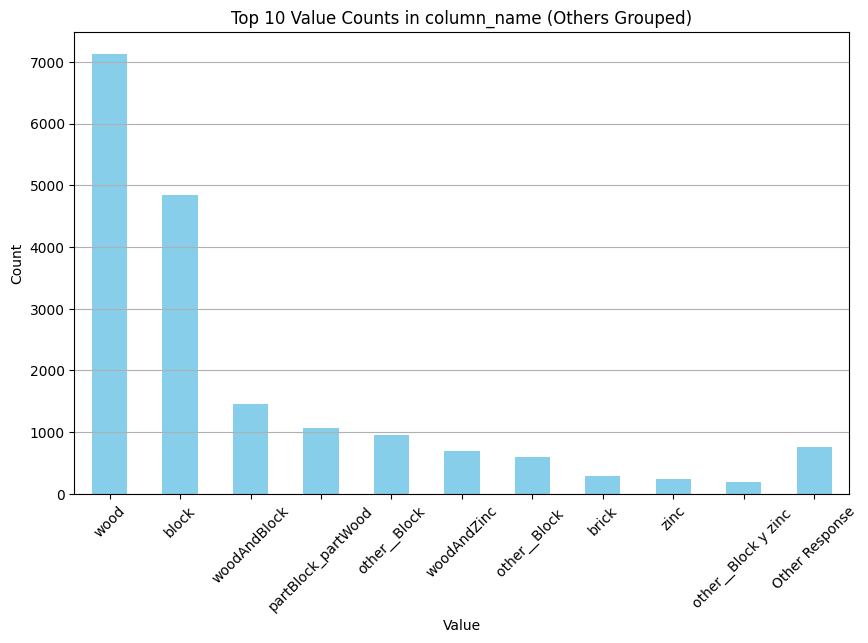

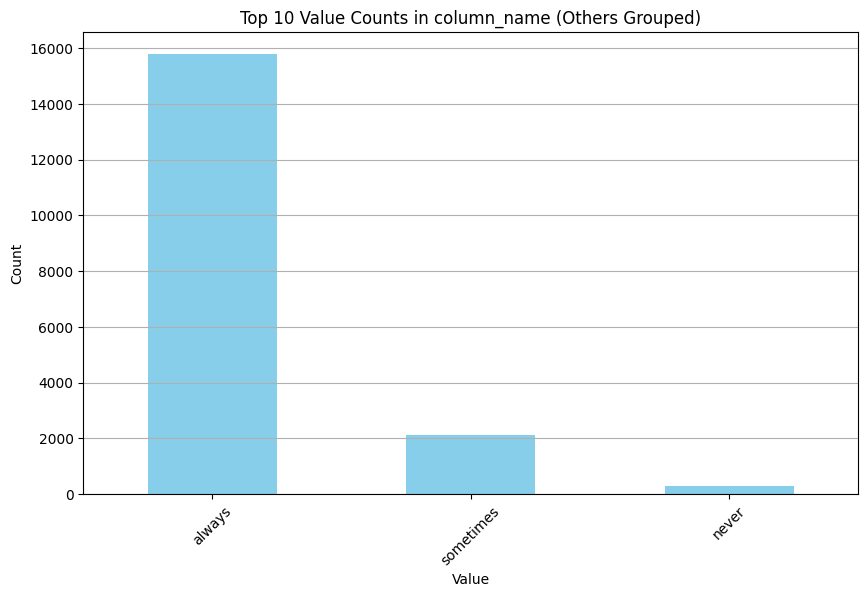

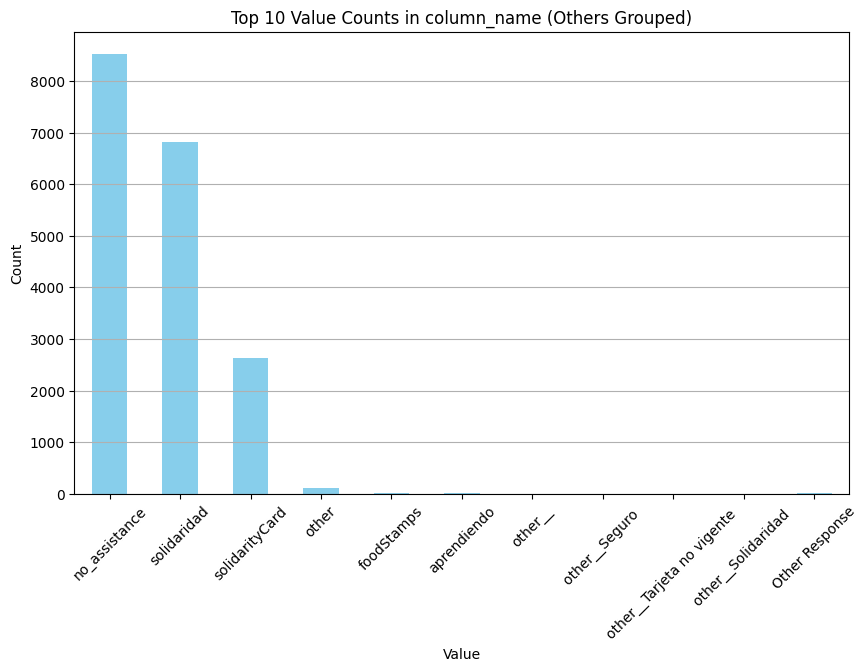

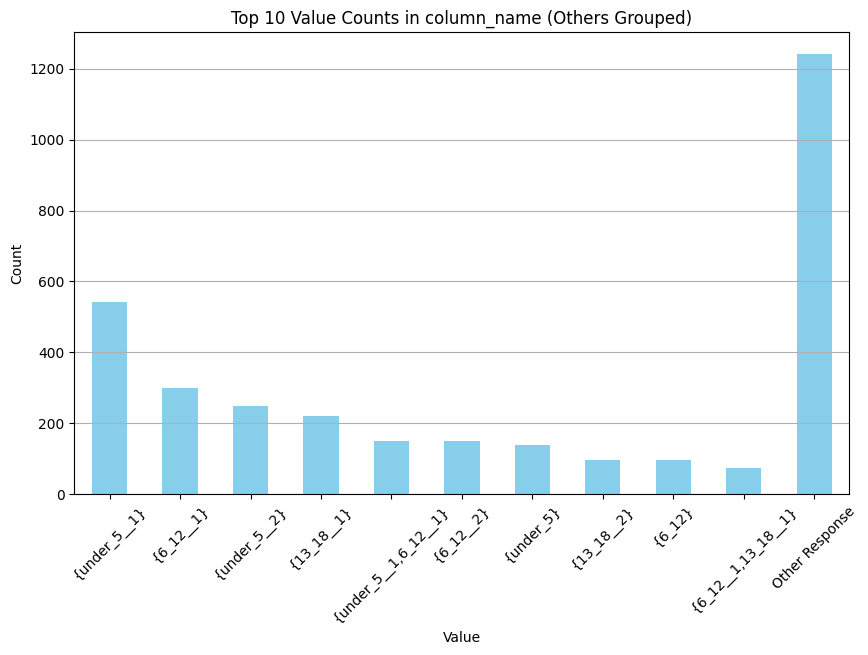

In [15]:
questions = env_health["question"].unique()
for question in questions:
    answer_counts = env_health.loc[env_health["question"] == question, "question_answer"].value_counts()

    if answer_counts.shape[0] > 10:
        # Get the top 10 values
        plot_df = answer_counts.nlargest(10)

        # Group all other values as "Other Response"
        other_count = answer_counts.iloc[10:].sum()
        plot_df['Other Response'] = other_count
    else:
        plot_df = answer_counts

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plot_df.plot(kind='bar', color='skyblue')
    plt.title('Top 10 Value Counts in column_name (Others Grouped)')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')

    # Show the plot
    plt.show()

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


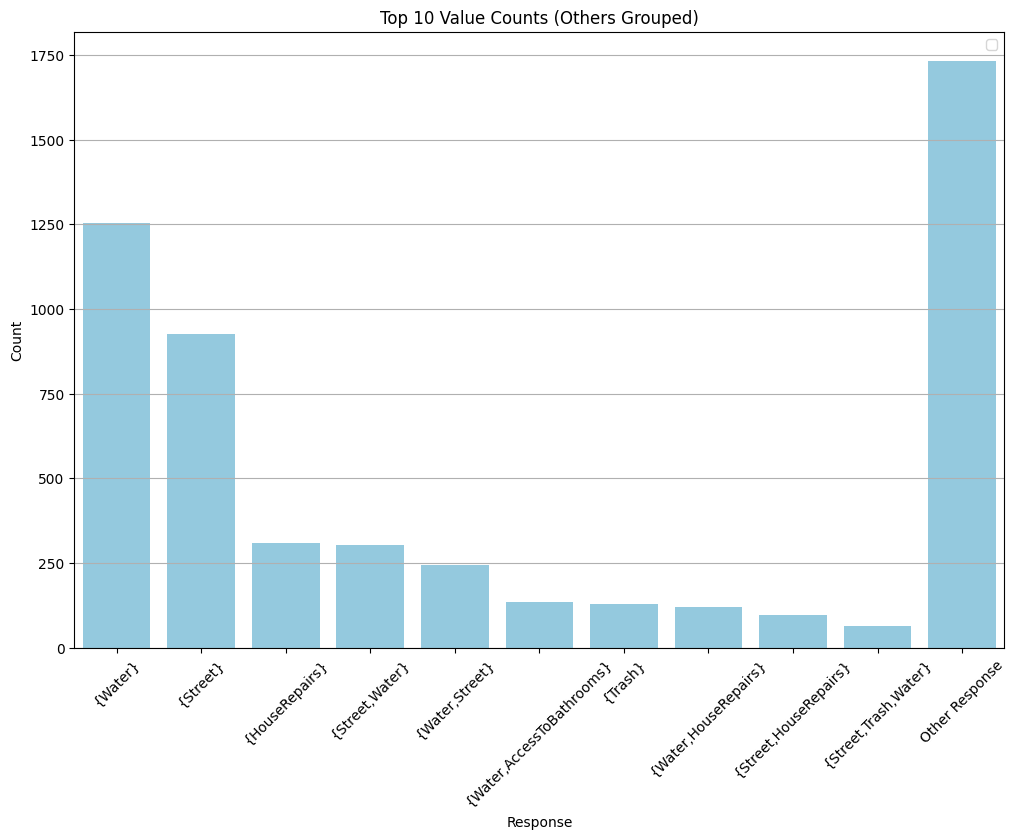

<Figure size 1200x800 with 0 Axes>

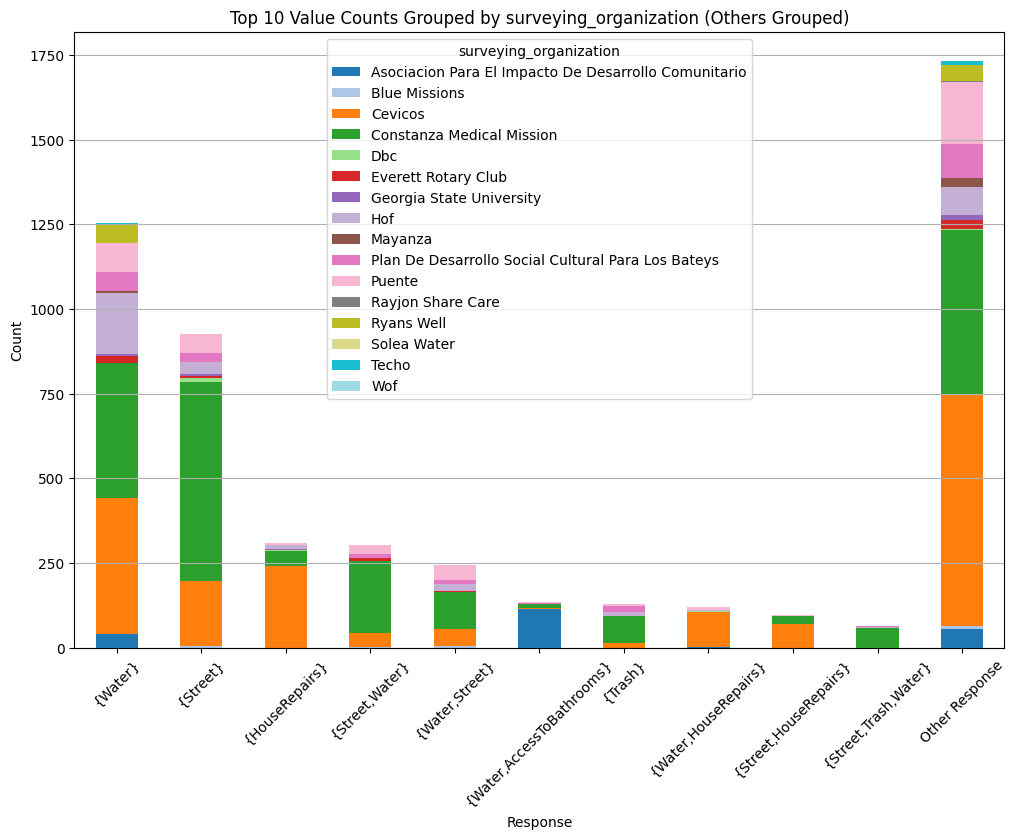

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


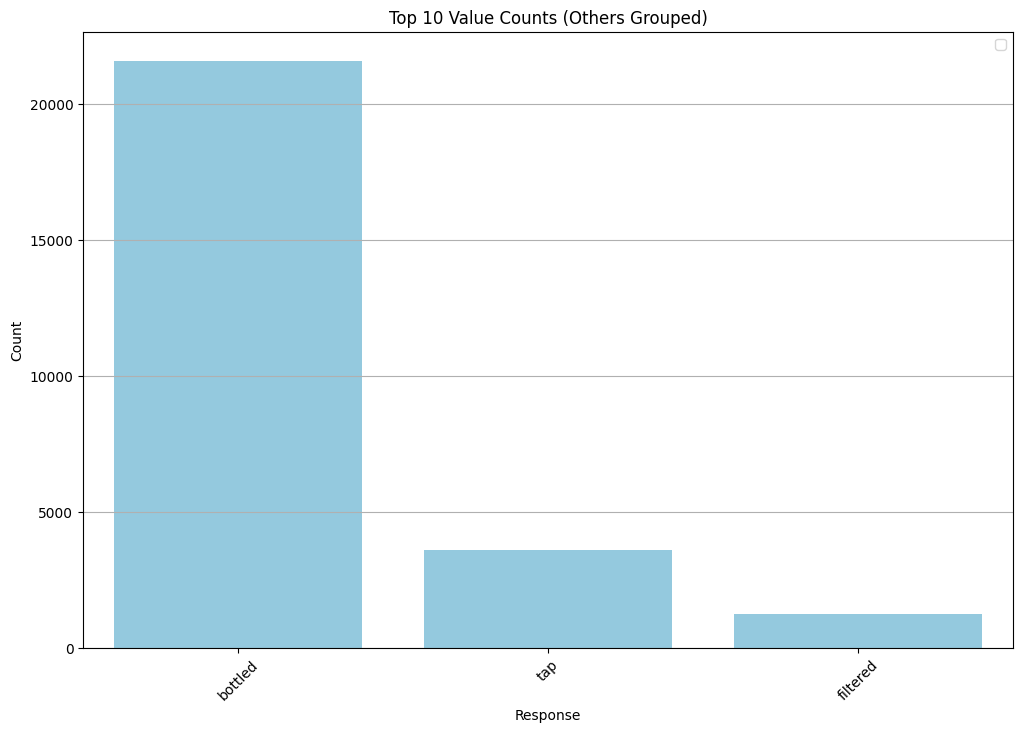

<Figure size 1200x800 with 0 Axes>

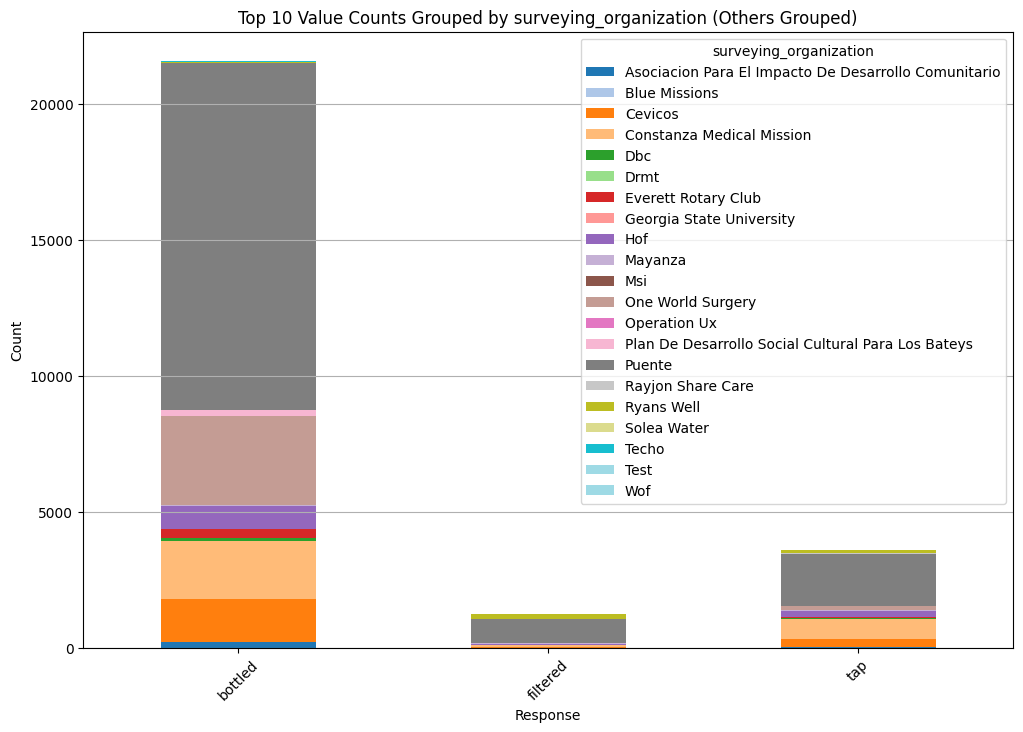

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


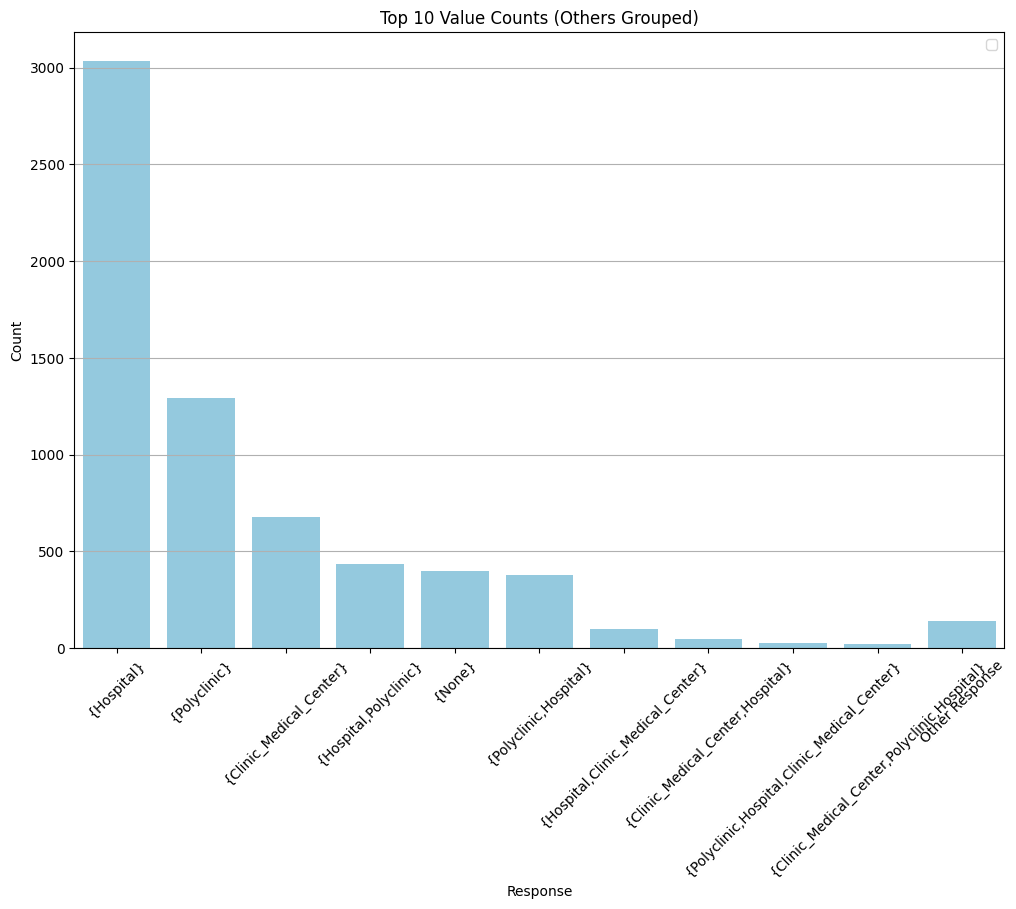

<Figure size 1200x800 with 0 Axes>

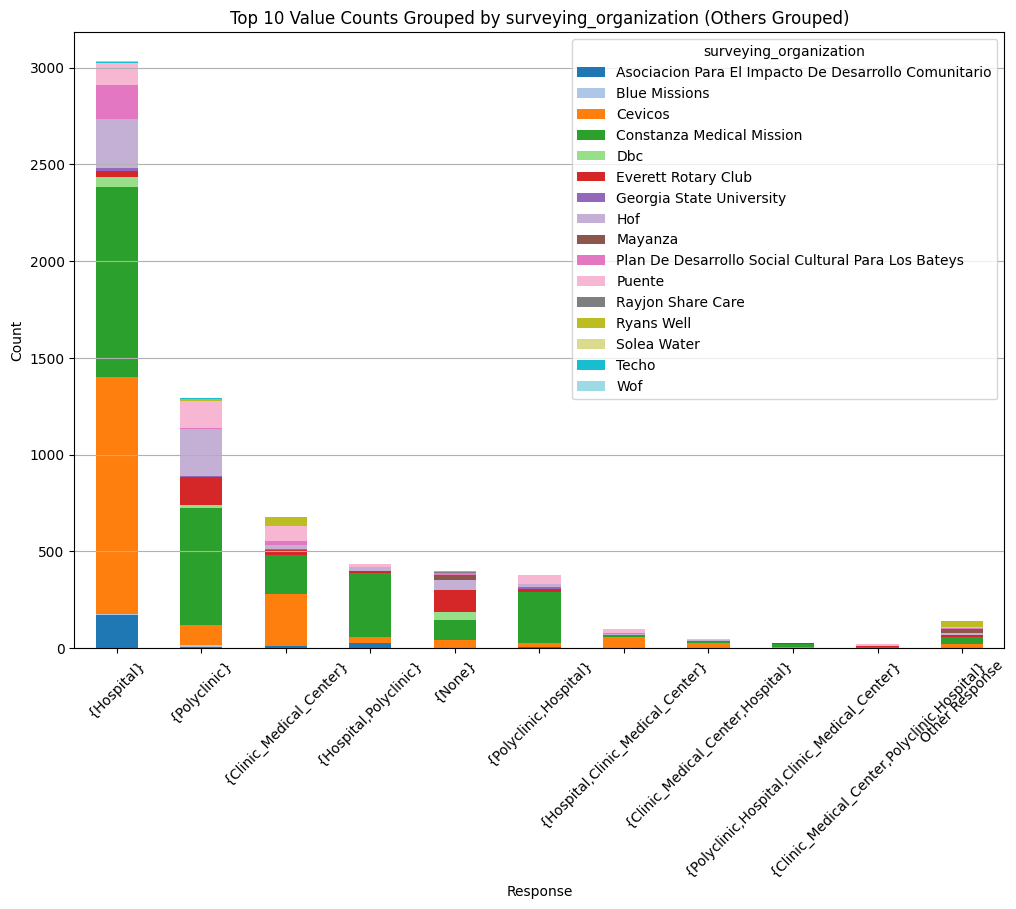

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


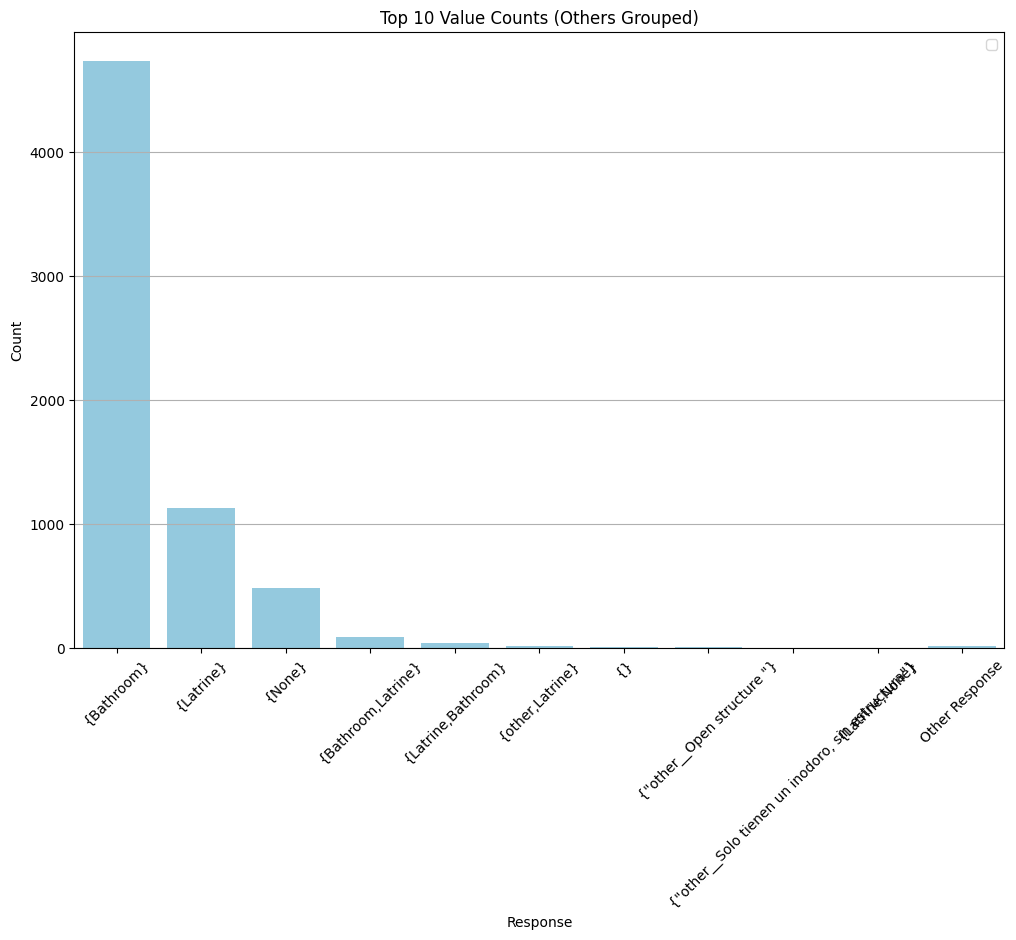

<Figure size 1200x800 with 0 Axes>

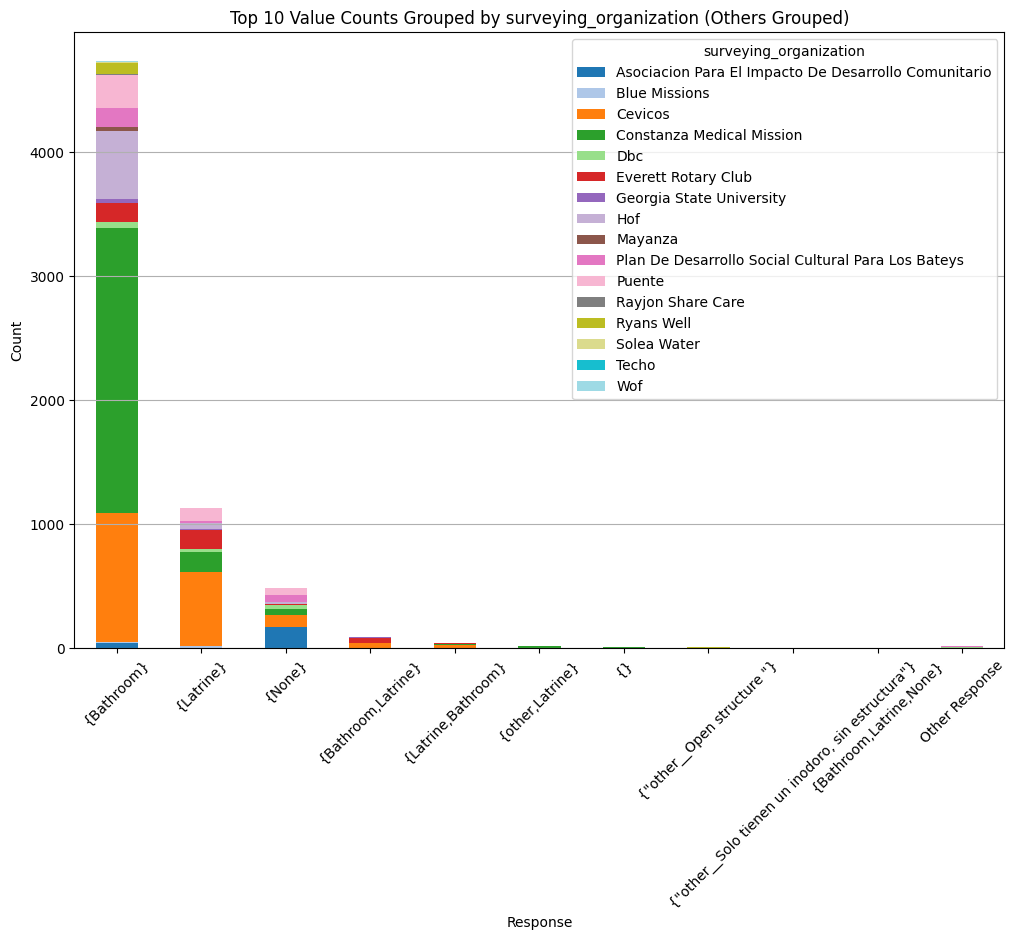

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


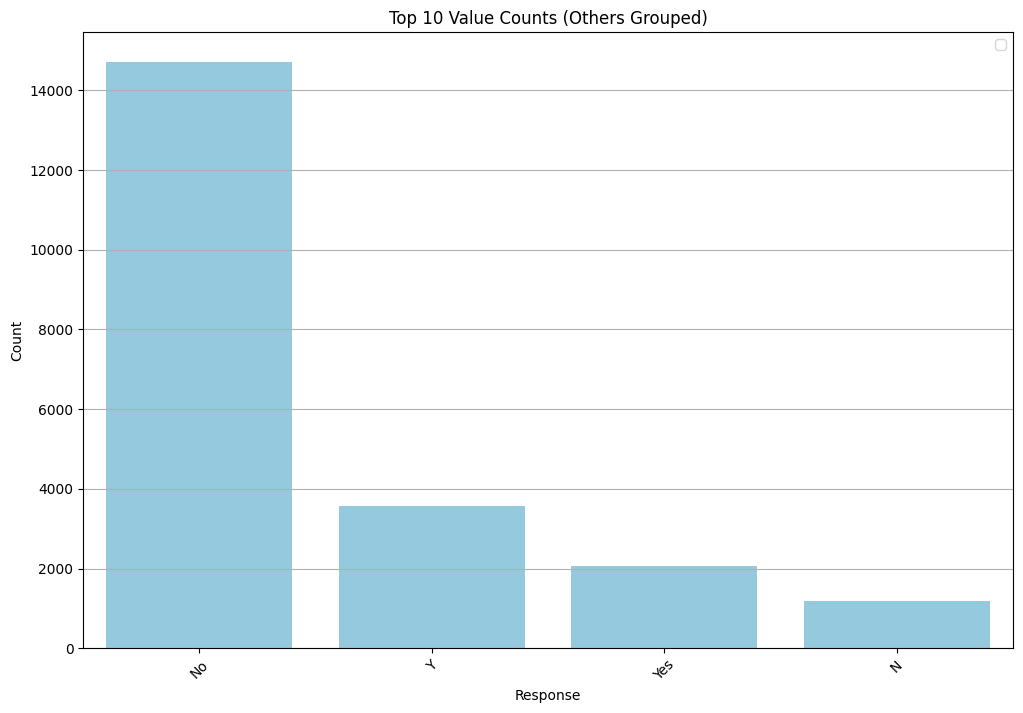

<Figure size 1200x800 with 0 Axes>

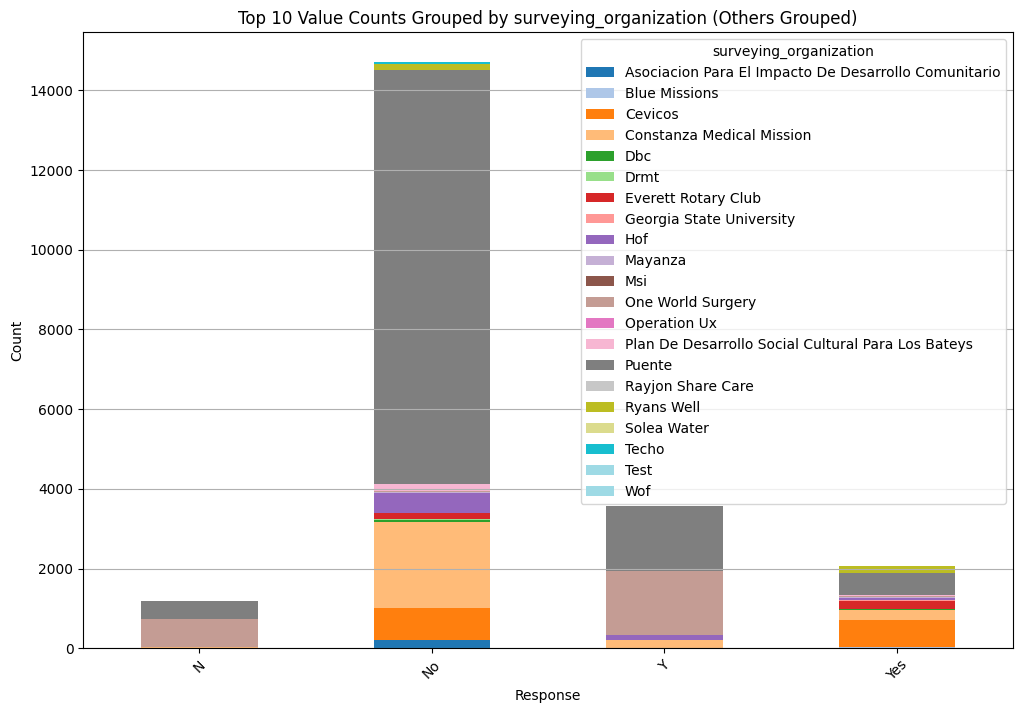

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


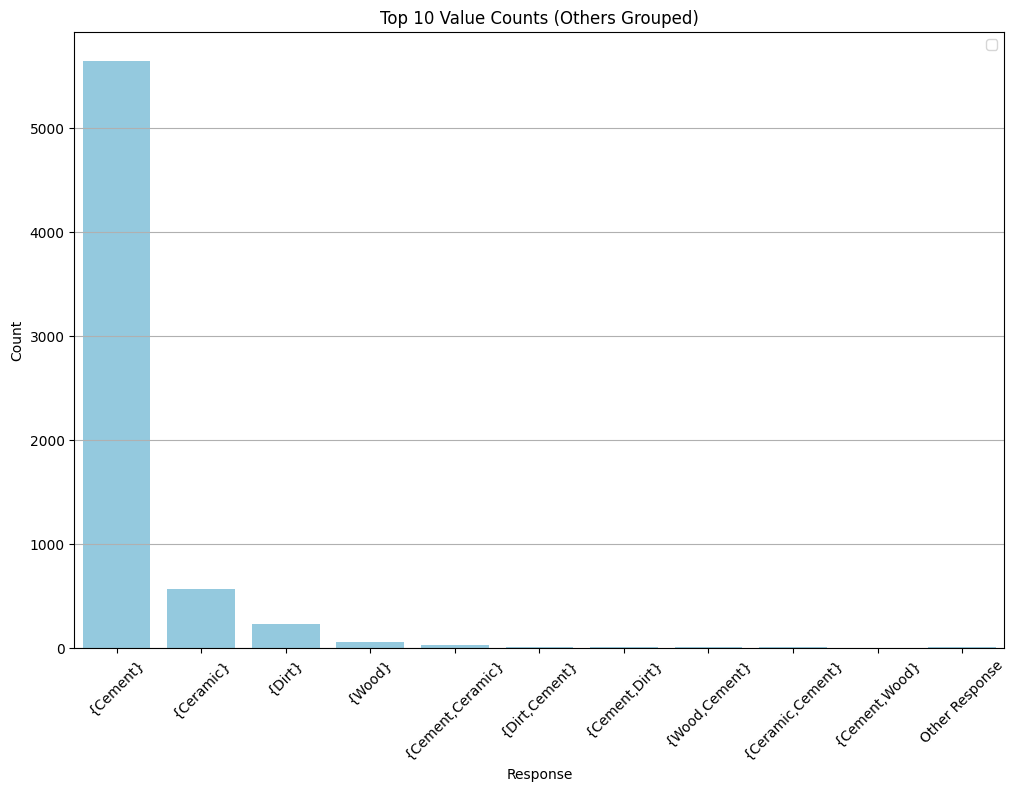

<Figure size 1200x800 with 0 Axes>

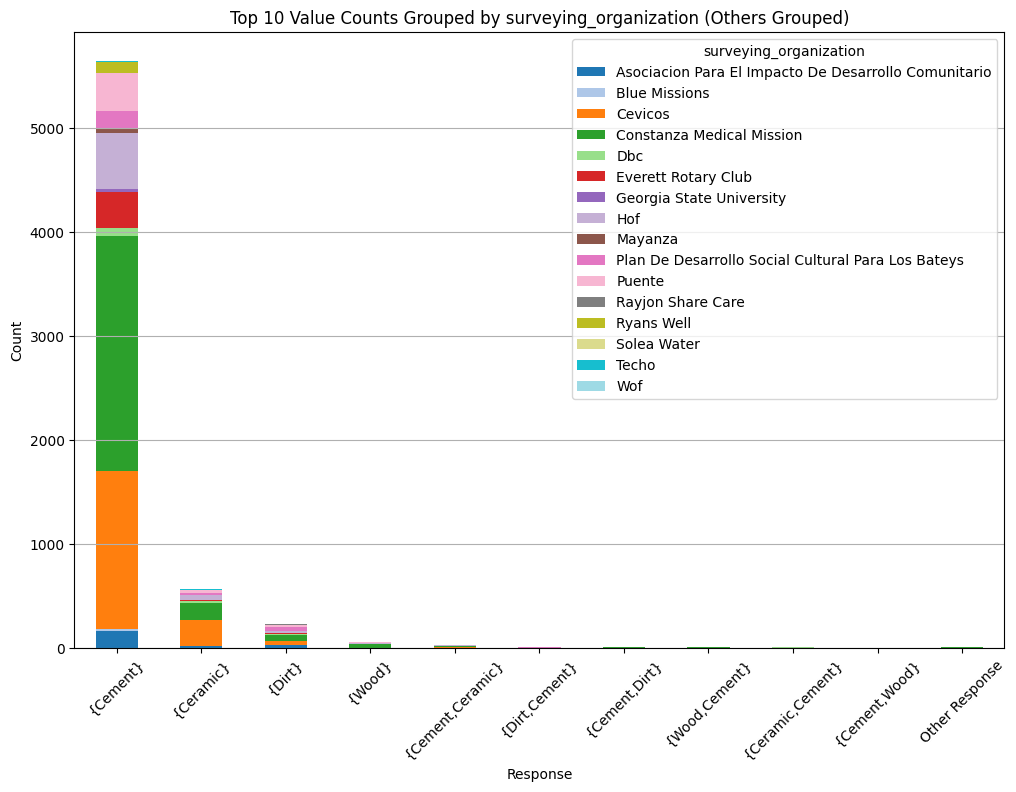

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


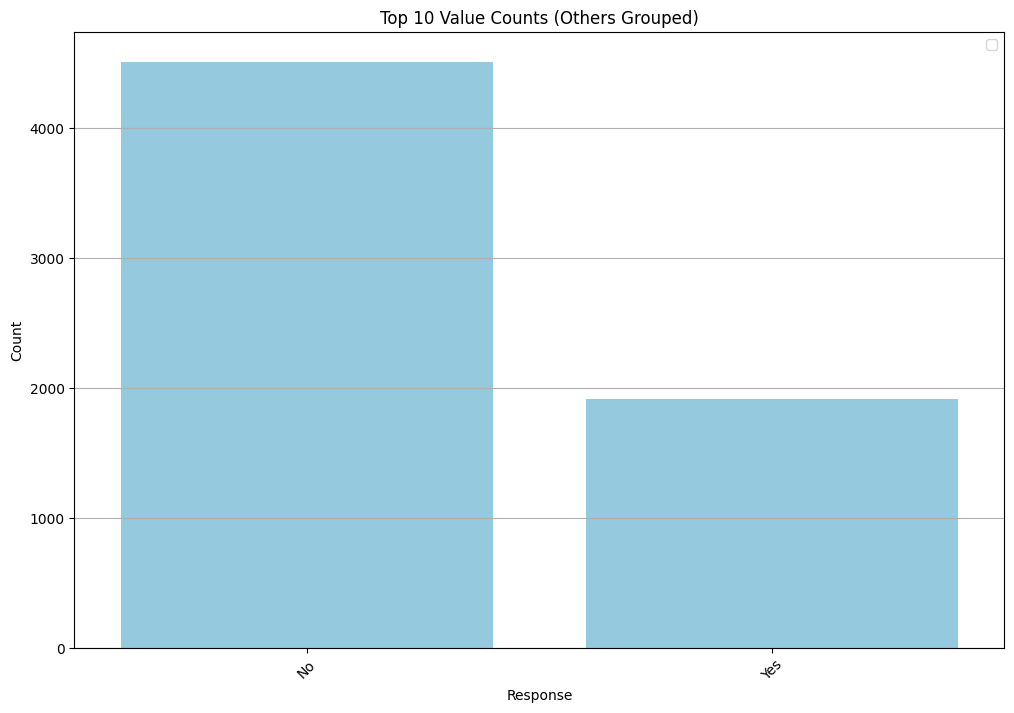

<Figure size 1200x800 with 0 Axes>

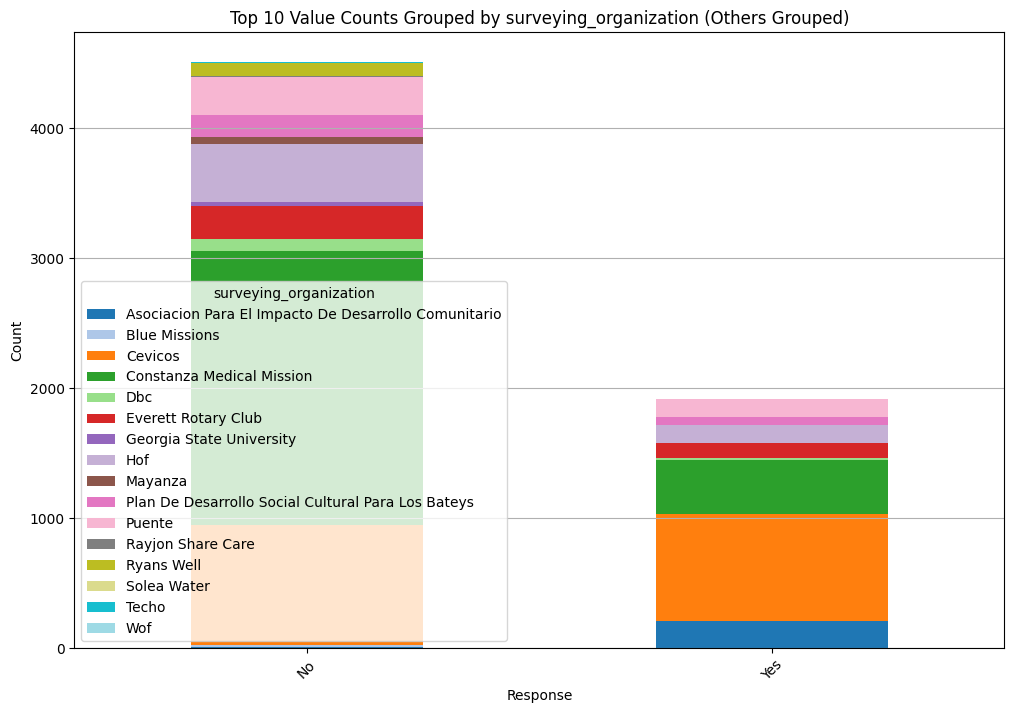

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


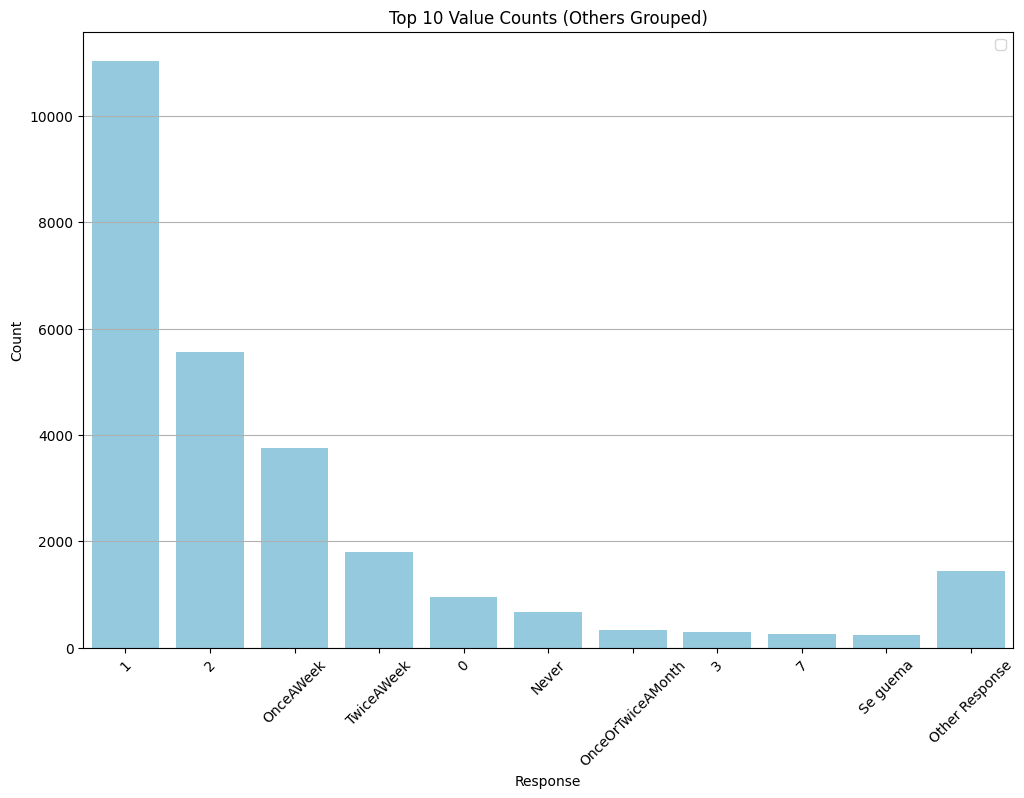

<Figure size 1200x800 with 0 Axes>

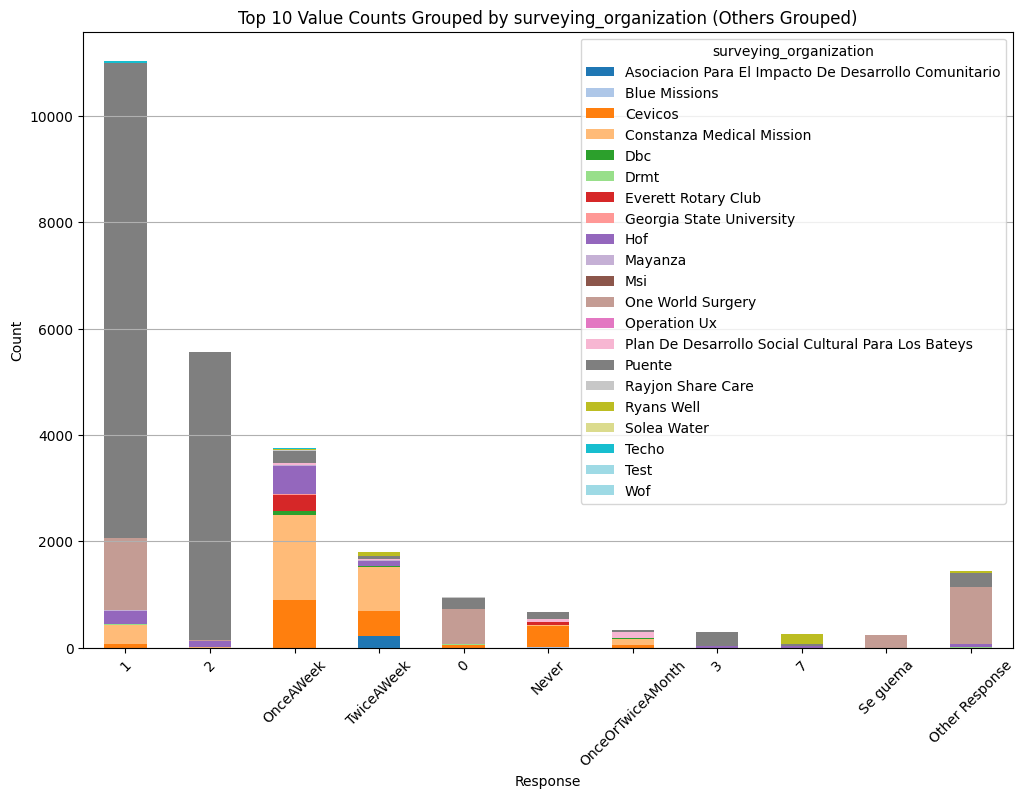

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


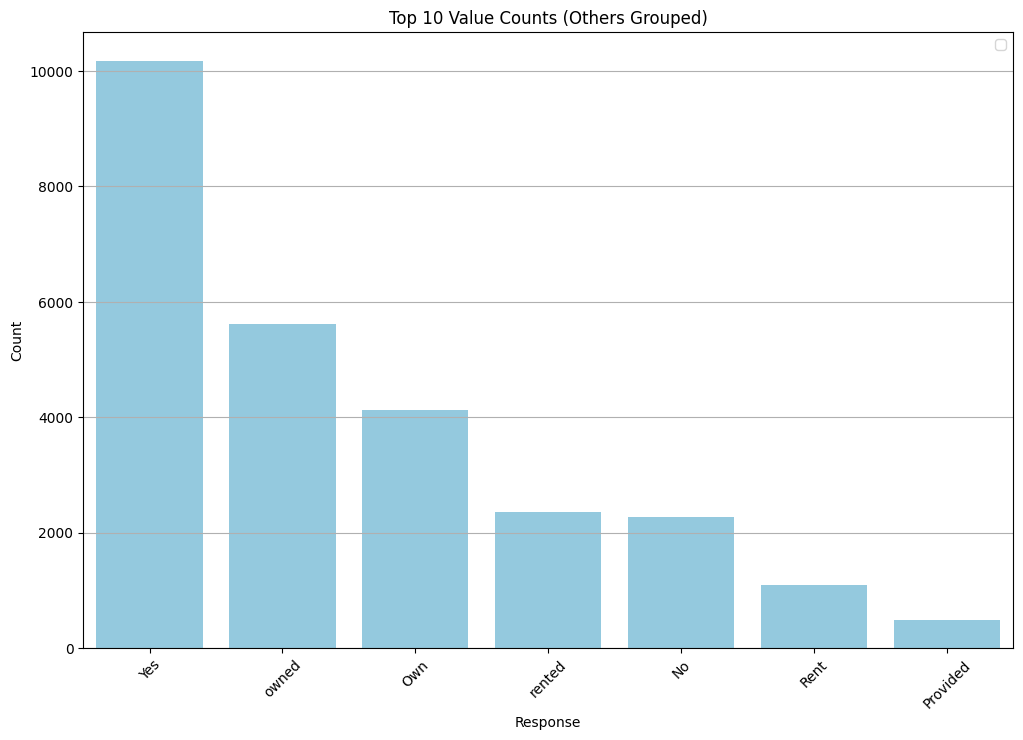

<Figure size 1200x800 with 0 Axes>

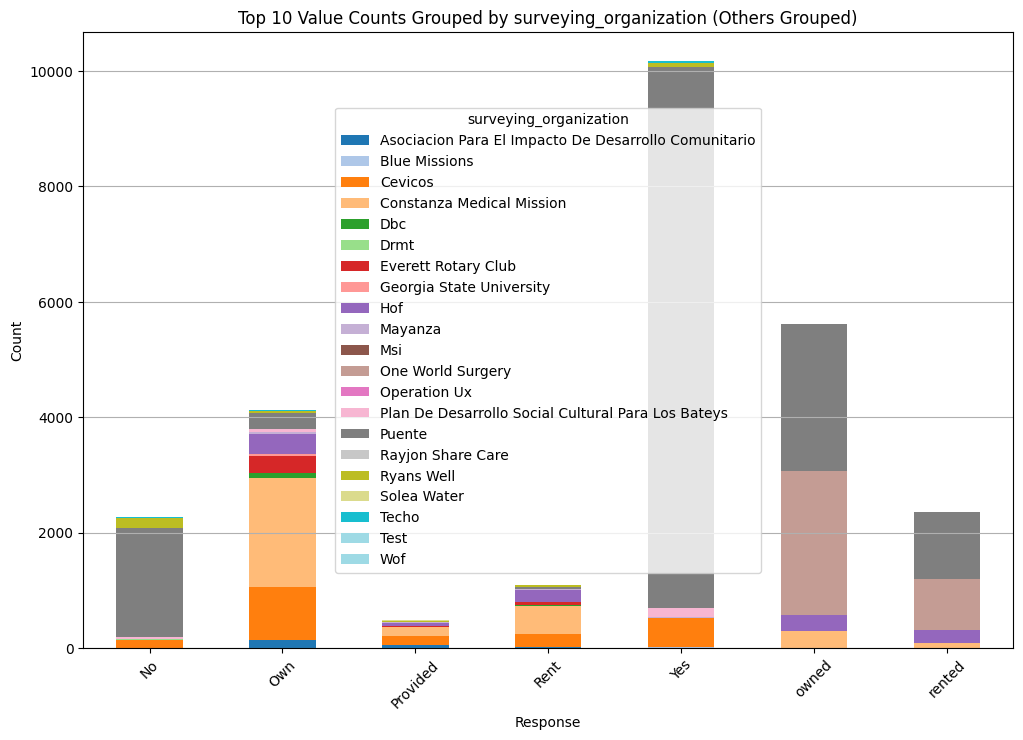

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


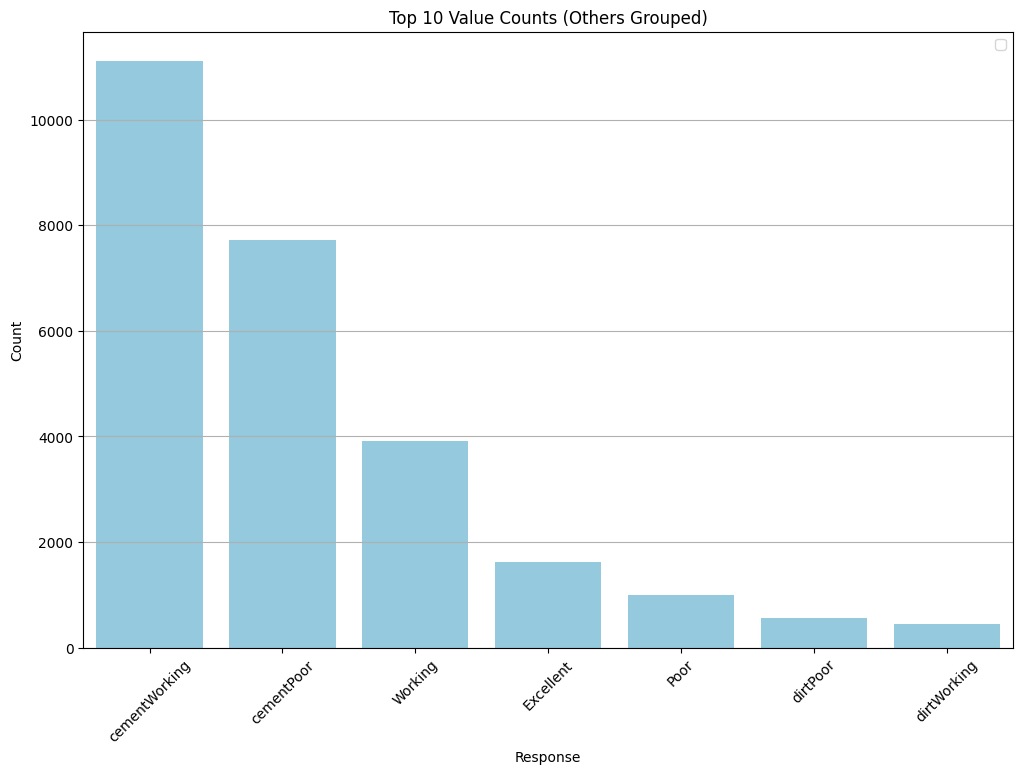

<Figure size 1200x800 with 0 Axes>

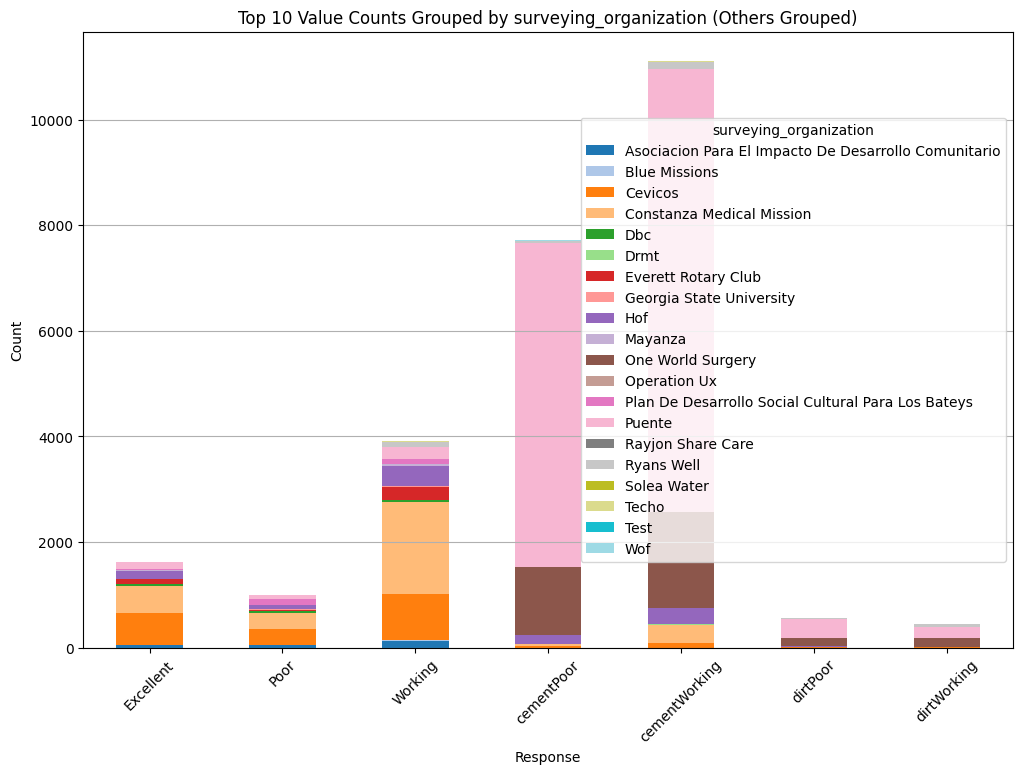

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


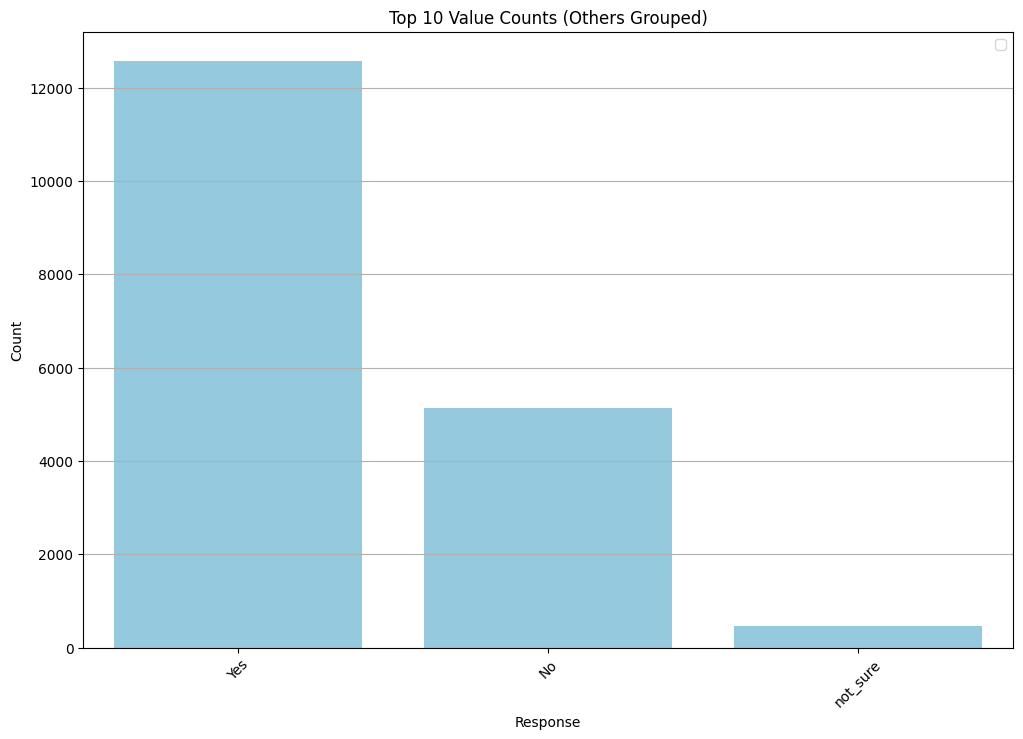

<Figure size 1200x800 with 0 Axes>

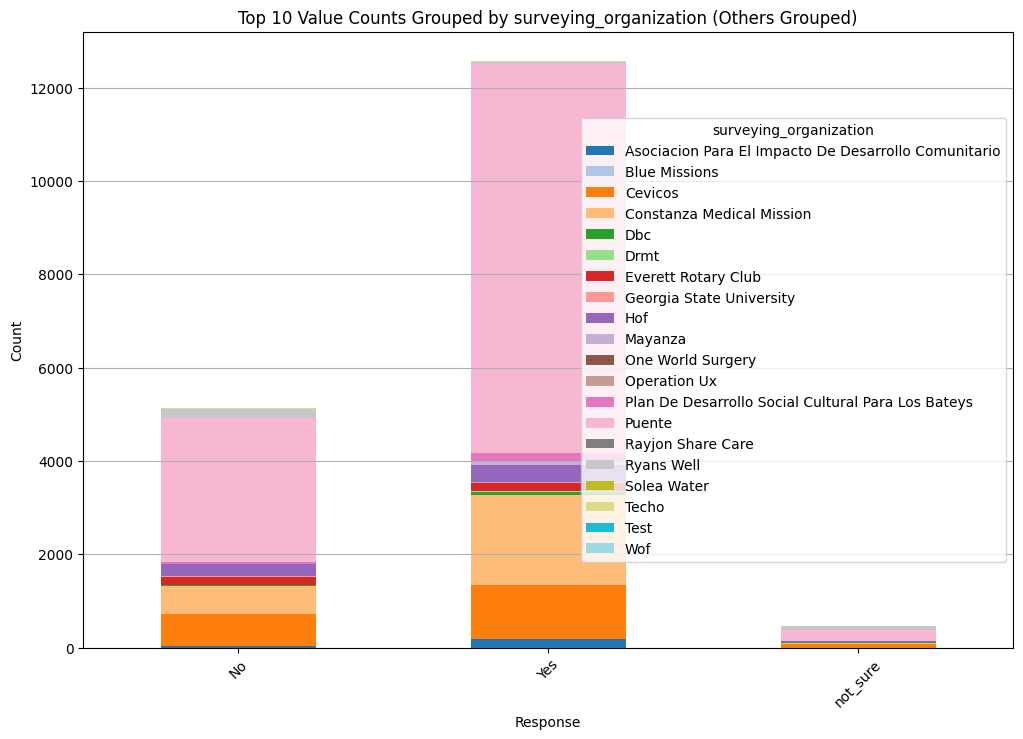

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


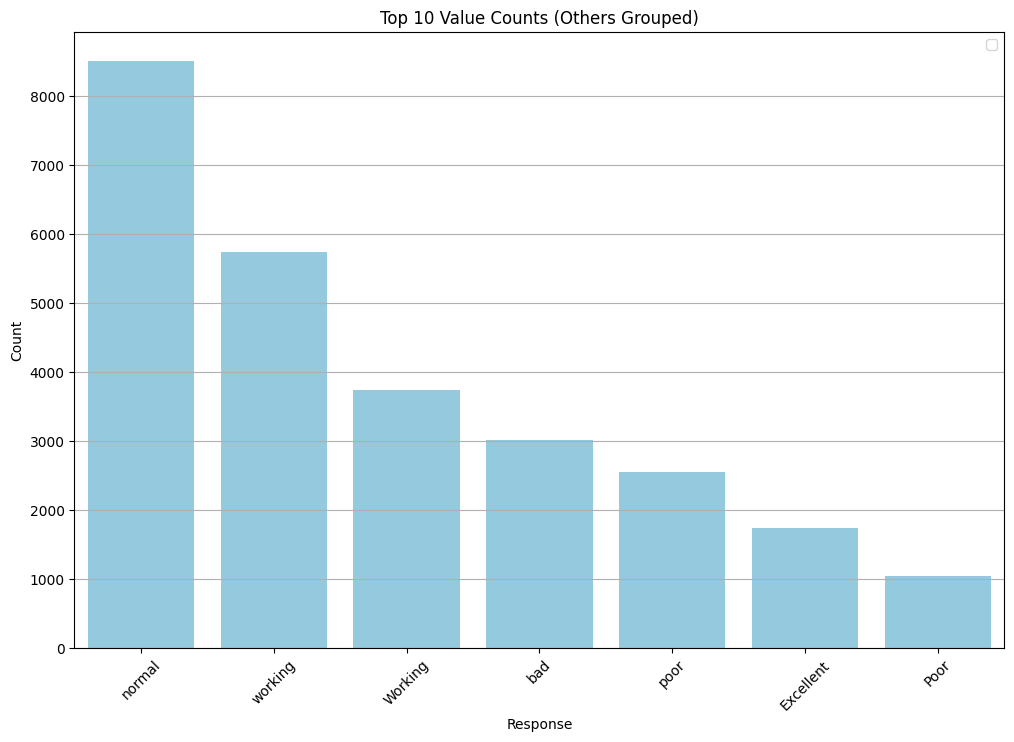

<Figure size 1200x800 with 0 Axes>

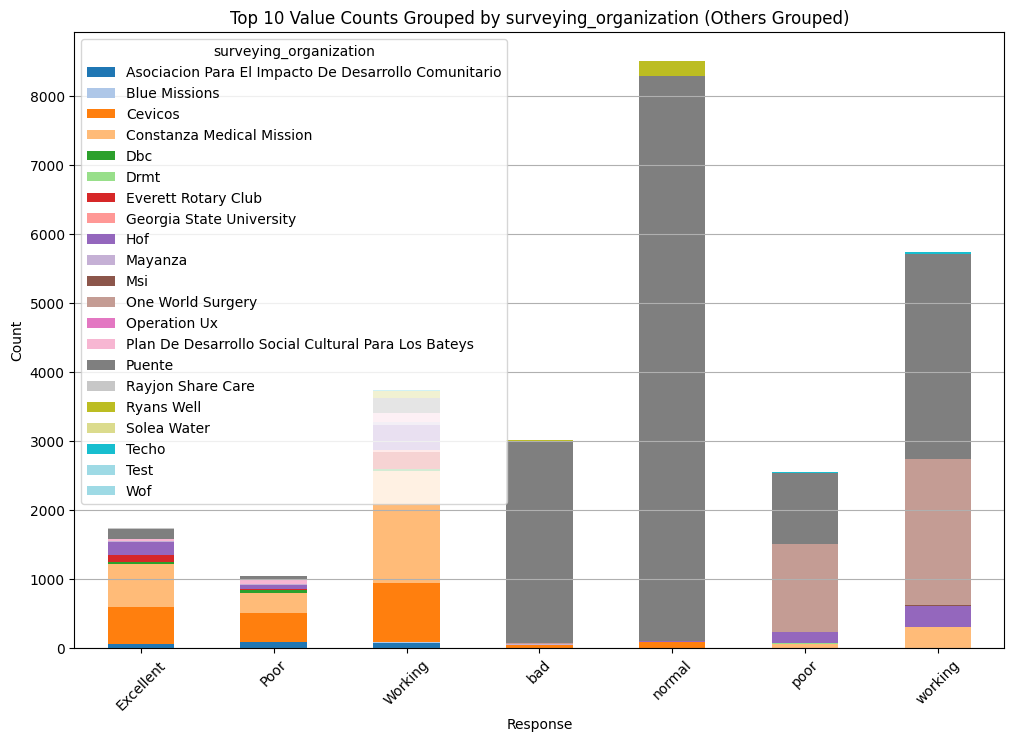

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


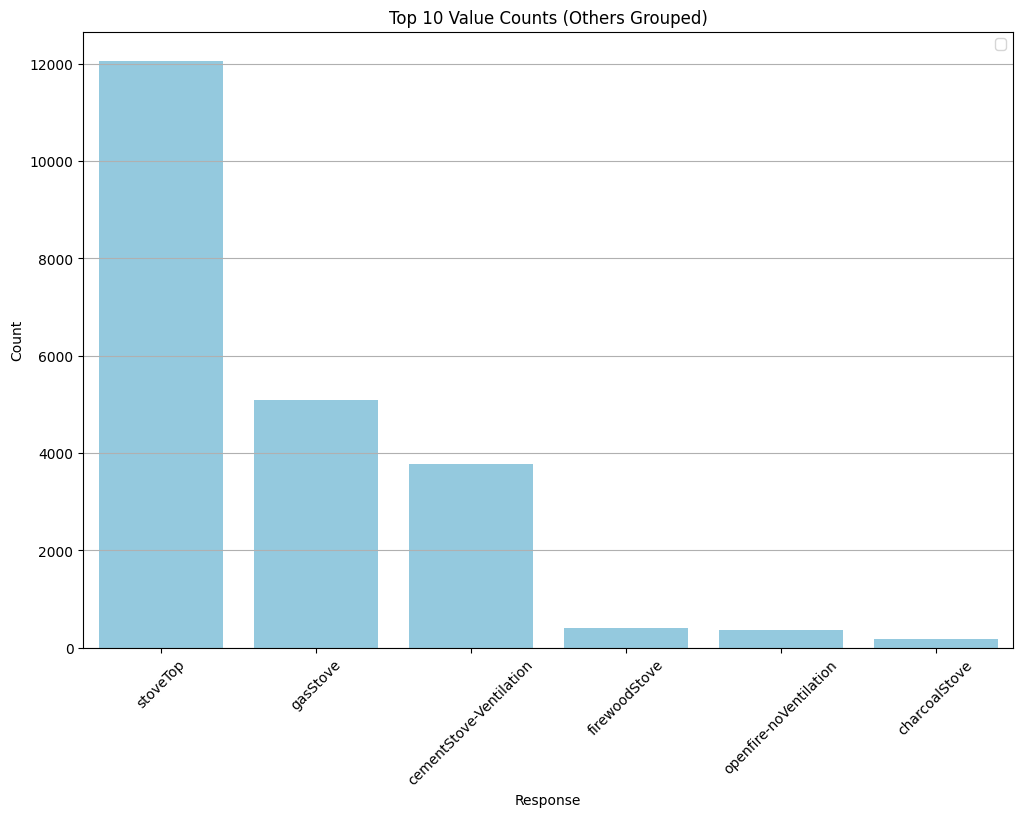

<Figure size 1200x800 with 0 Axes>

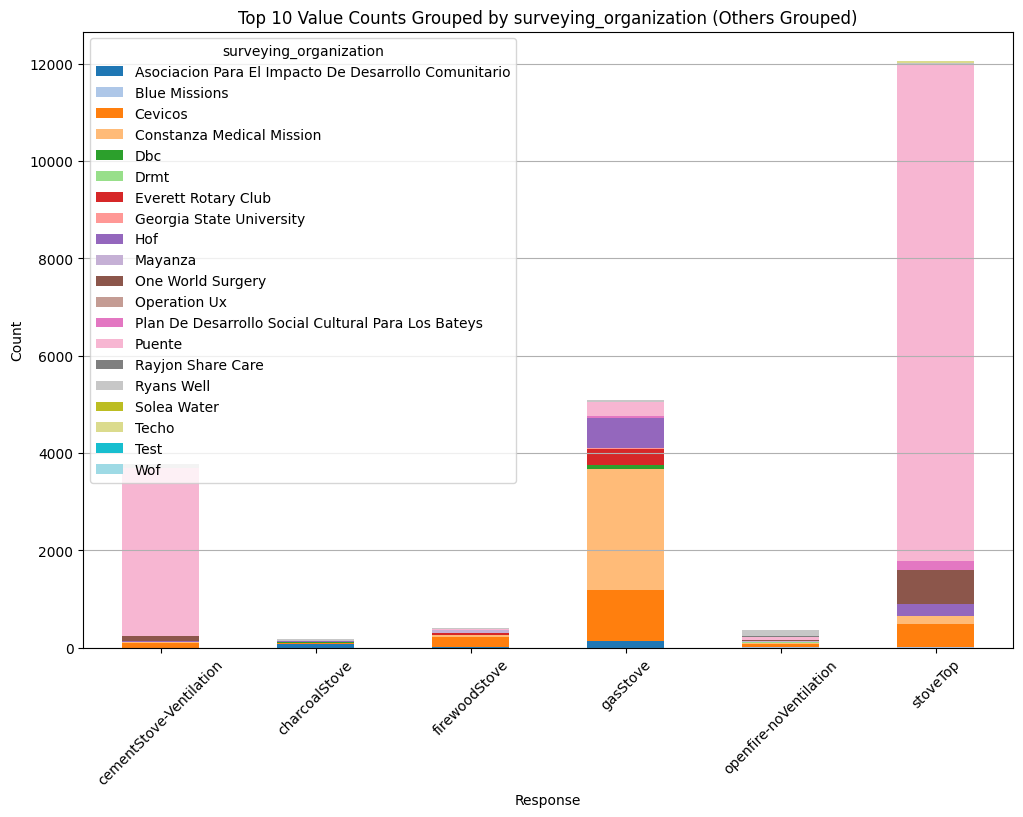

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


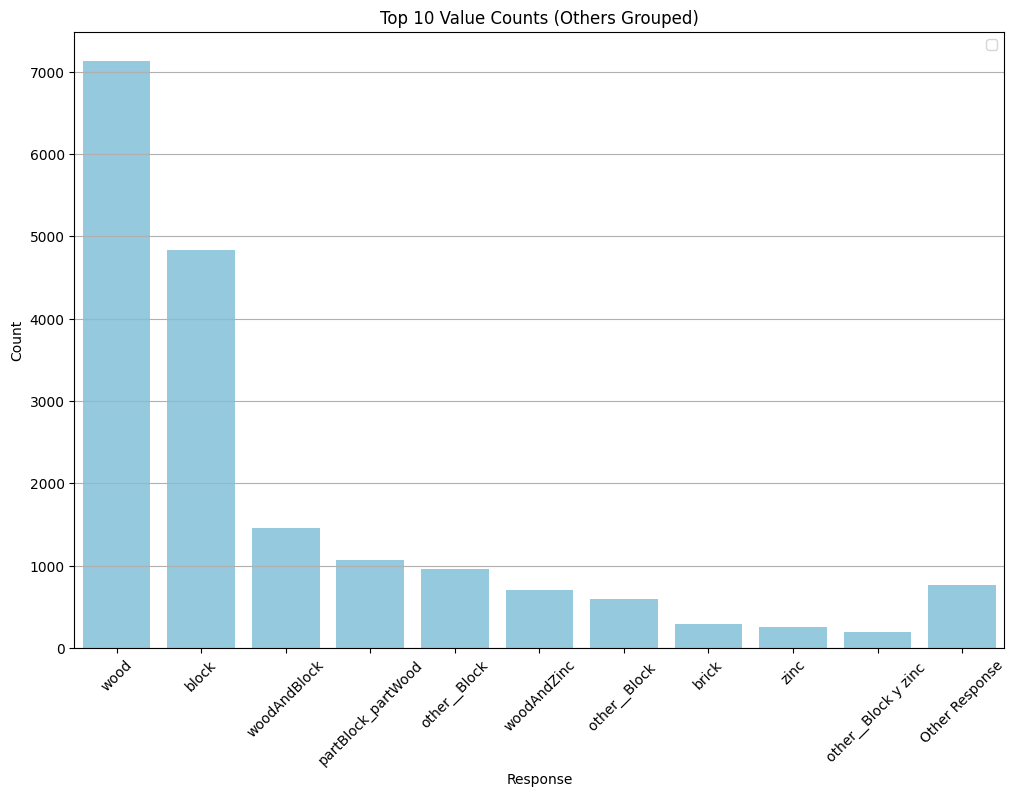

<Figure size 1200x800 with 0 Axes>

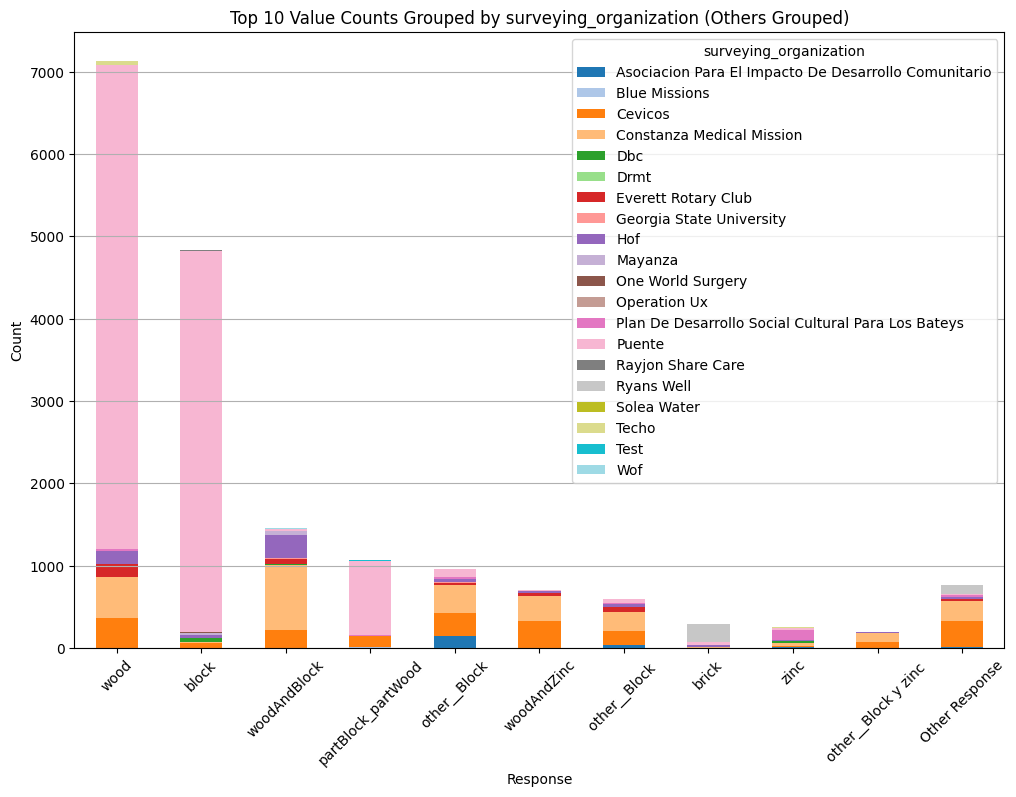

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


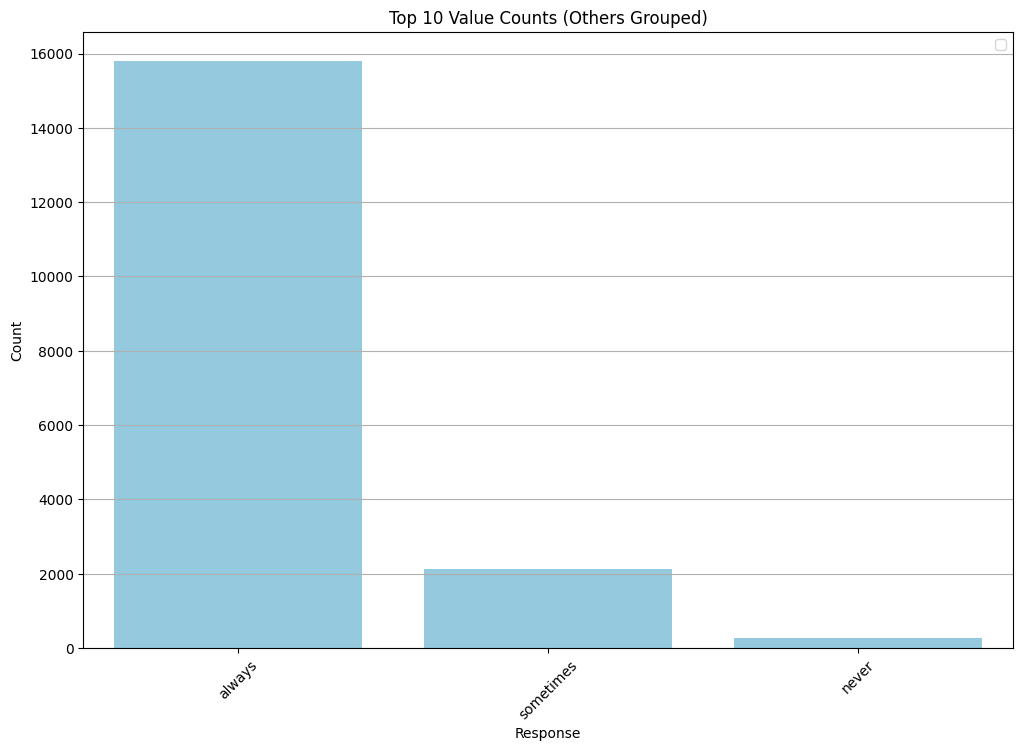

<Figure size 1200x800 with 0 Axes>

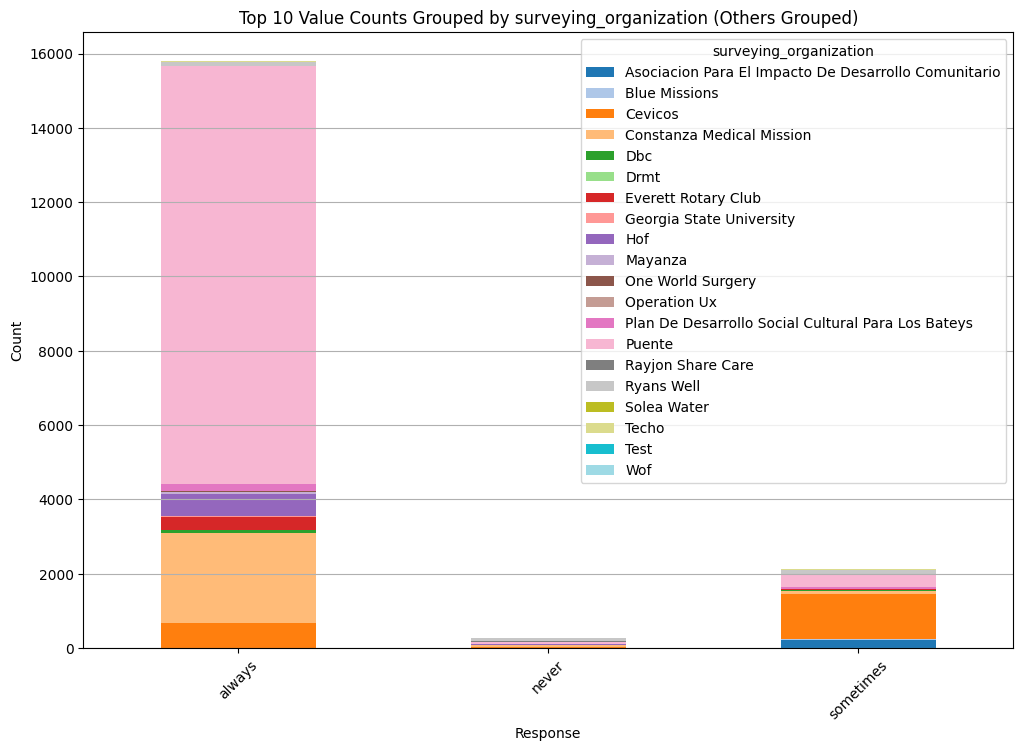

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


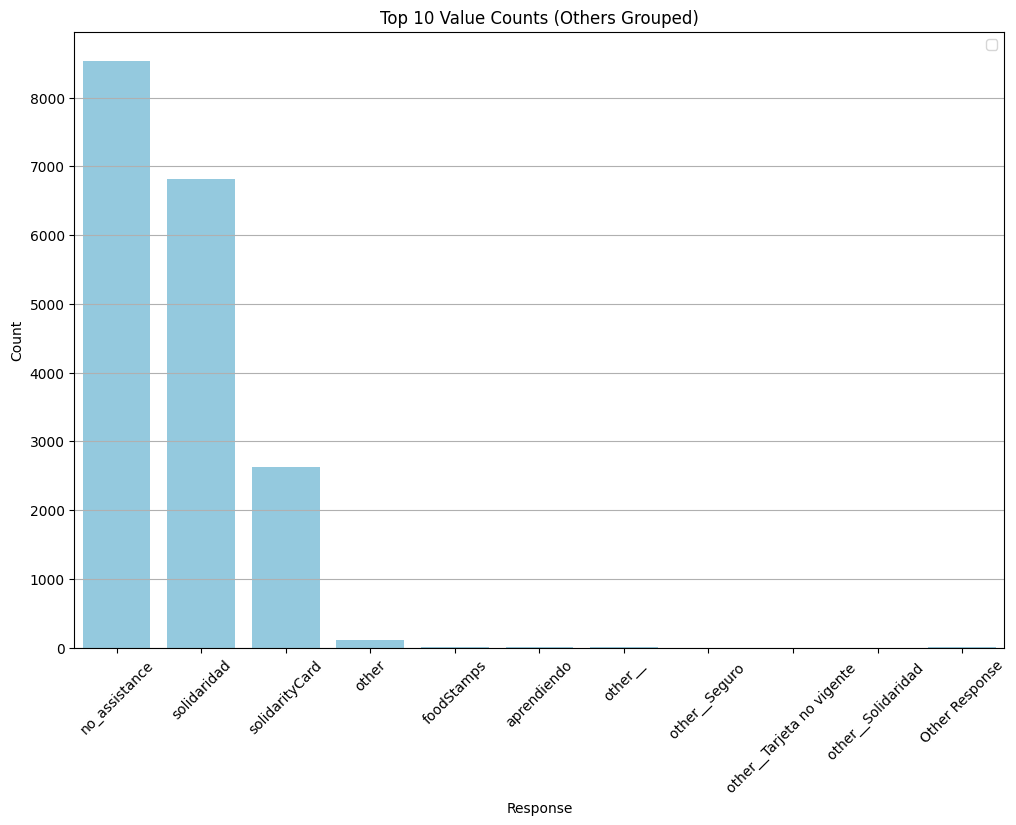

<Figure size 1200x800 with 0 Axes>

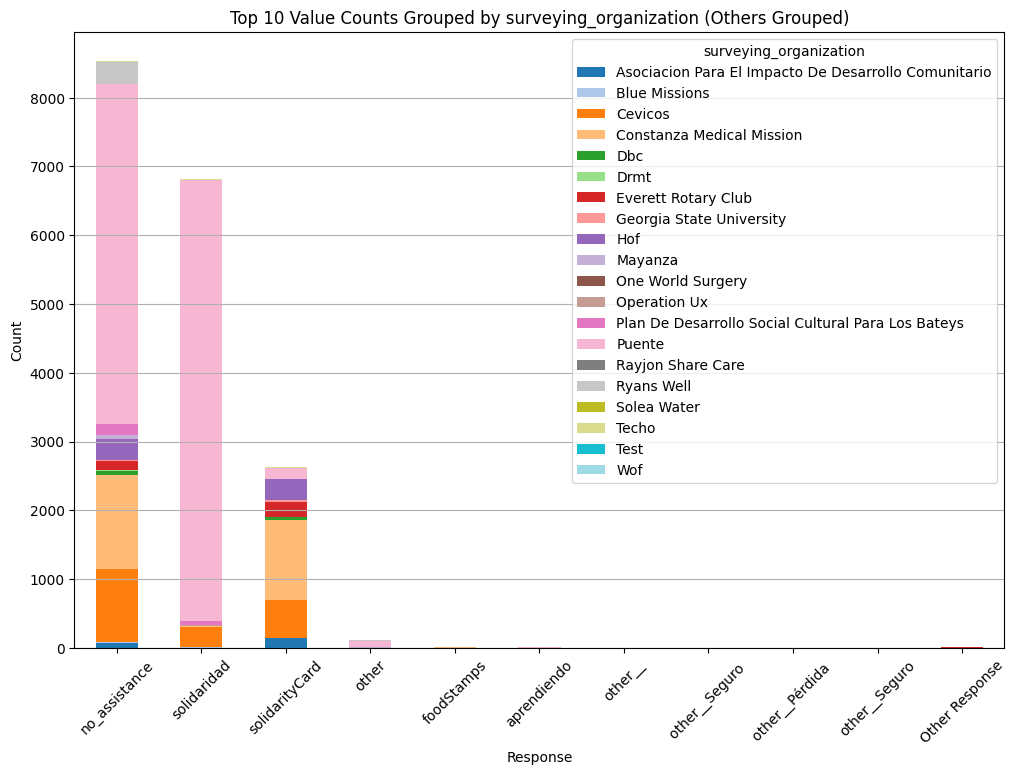

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_11676\3796298335.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


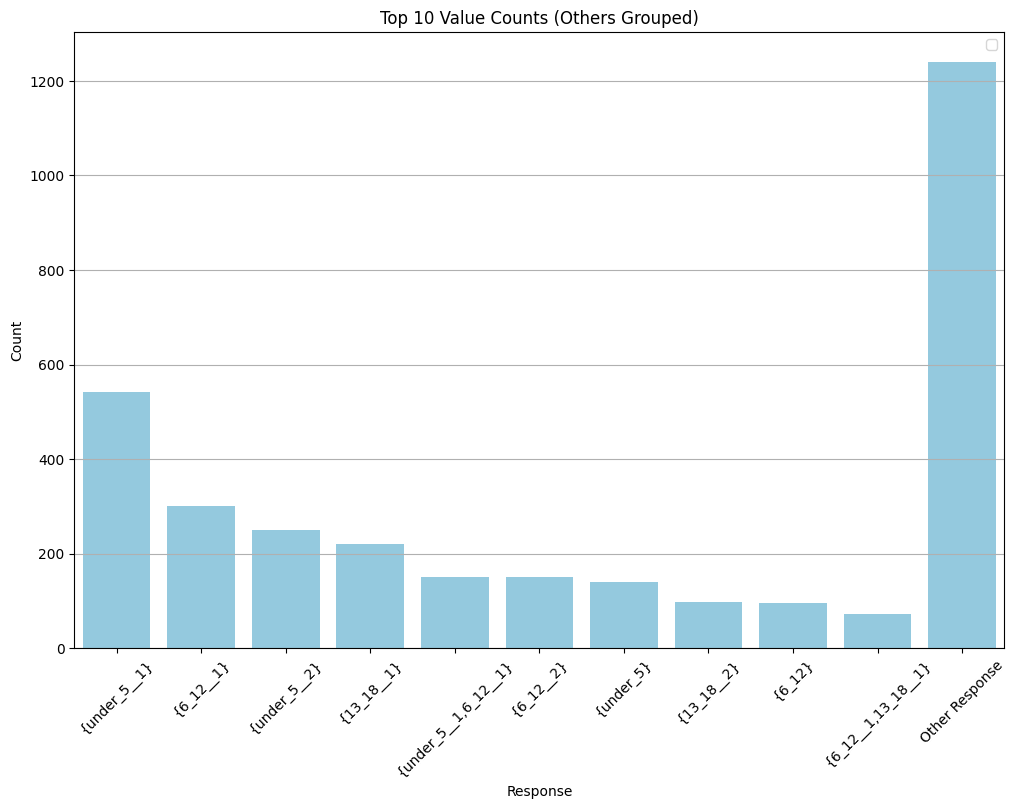

<Figure size 1200x800 with 0 Axes>

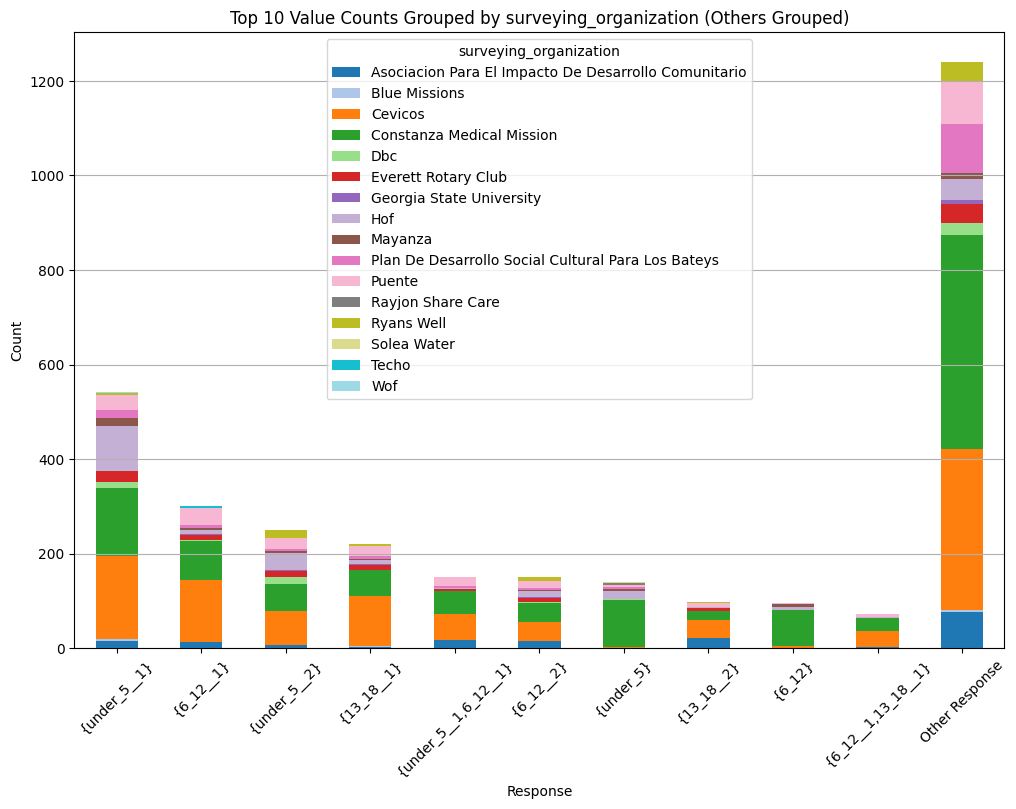

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_responses(df, response_column="question_answer", grouping_column=None):
    # Count the occurrences of each value in the specified column grouped by the optional grouping columns
    if grouping_column:
        answer_counts = df.groupby([response_column, grouping_column]).size().unstack(fill_value=0)
    else:
        answer_counts = df[response_column].value_counts().to_frame()
    
    if answer_counts.shape[0] > 10:
        # Get the top 10 values
        top_10_responses = answer_counts.sum(axis=1).nlargest(10).index

        # Group all other values as "Other Response"
        plot_df = answer_counts.loc[top_10_responses]
        plot_df.loc['Other Response'] = answer_counts.drop(top_10_responses).sum()
        # Reset index for plotting
        # Prepare the data for plotting
        plot_df = plot_df.reset_index()

        # Plot the stacked bar chart
        plot_df.set_index(response_column, inplace=True)
        
    else:
        plot_df = answer_counts.copy()  

    # Plot the stacked bar chart using seaborn
    plt.figure(figsize=(12, 8))
    if grouping_column:
        plot_df.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
        plt.title(f'Top 10 Value Counts Grouped by {grouping_column} (Others Grouped)')
        #sns.barplot(x="question_answer", y='count', hue=grouping_column, data=plot_df, palette='tab20', estimator=sum)
    else:
        sns.barplot(x="question_answer", y='count', data=plot_df, color="skyblue", estimator=sum)
        plt.title('Top 10 Value Counts (Others Grouped)')
    plt.xlabel("Response")
    plt.ylabel('Count')
    plt.legend(title=grouping_column)
    plt.xticks(rotation=45)
    plt.grid(axis='y')

    # Show the plot
    plt.show()


for question in questions:
    question_df = env_health[env_health["question"]==question]
    # plot all responses
    plot_top_responses(question_df)
    # plot all responses, grouped by survey org
    plot_top_responses(question_df, grouping_column="surveying_organization")